# CodeSearchNet — LoRA Prep, Step 0: Task Feasibility & Target-Model Checks

This is **Step 0 of the third notebook** in the Copilot Code project (RAG + LoRA +
Agent) — it comes *before* NB3's actual prompt/response-pair construction (Plan
Step 2ב), not instead of it.

**Why this exists as a separate step:** NB2 (`codesearchnet_pipeline_v3`) validated
and saved the raw data (`train_df` / `val_df` / `test_df` parquet), but every check
in NB2 used the **embedding model's** tokenizer (`all-MiniLM-L6-v2`) and said
nothing about whether fine-tuning is worth doing at all, or which direction the
task should run. Building NB3's prompt-formatting logic before answering those
questions risks building the wrong thing.

**What this notebook checks, in order — each one can change what comes after it:**
1. **Baseline feasibility** — does the un-tuned target model already do this task
   reasonably well? If so, LoRA has little to add in that direction.
2. **Task direction decision** — `doc→code` or `code→doc`, decided from evidence
   in Step 1, not left open.
3. **Cross-split template overlap** — a cheap check for repeated docstring
   *structure* (not just duplicate code) leaking signal between train and val/test.
4. **Target-model tokenizer budget** — re-run NB2's 512-token check, but against
   the actual LoRA model's tokenizer instead of the embedding model's.
5. **Balanced LoRA subsample** — pick the actual few-hundred-row training set from
   the 18,730 available train rows, applying the same per-repo balance principle
   NB2 already used for the train/val/test split itself.

**Models compared throughout (8 total):** the original two candidates from Plan
Step 2א — `microsoft/Phi-3-mini-4k-instruct` and `Qwen/Qwen2.5-Coder-1.5B-Instruct`
— plus six more added after Step 0.1's first run raised the question of whether a
different model in the same size class does better: `Qwen/Qwen2.5-Coder-3B-Instruct`,
`deepseek-ai/deepseek-coder-1.3b-instruct`, `bigcode/starcoder2-3b`,
`google/codegemma-2b`, `microsoft/Phi-3.5-mini-instruct`, and
`meta-llama/Llama-3.2-3B-Instruct`. Two of the eight (StarCoder2-3B, CodeGemma-2B)
are base/completion models with no chat template — included anyway as a
code-specific "no instruction-tuning" comparison point, handled with a prompting
fallback (see Step 0.1's generation cell). Llama-3.2-3B-Instruct is gated on
Hugging Face and needs a token with the license accepted (see Step 0.0b).

With 8 models this notebook loads and frees one model at a time rather than
holding all of them on the GPU together — see Step 0.1's loading cell for why.

**Also new:** Step 0.1c adds a GPT-as-judge score on top of the manual read and
the ROUGE-L/syntax-validity metrics — a general-purpose LLM (used only as a
judge here, not as a LoRA candidate) scores every generated output against the
ground truth on a 1-5 scale. Needs `OPENAI_API_KEY` as a Colab secret; skipped
gracefully if it's missing. (A second judge, Gemini, was tried and dropped — its
model name turned out to be deprecated on a real run; see Step 0.1c.)

**Not in scope here:** actually building the prompt/response pairs or running
LoRA training — that is the rest of NB3, and it should only start once this
notebook's five checks have real answers.


## Step 0.0: Setup

This notebook needs `train_df` / `val_df` / `test_df` exactly as NB2
(`codesearchnet_pipeline_v3`) built and saved them. It no longer requires NB2 to
have actually been *run* first, though — if `codesearchnet_pipeline_output/` already
has NB2's parquet files (e.g. from an earlier run in this same environment), they're
loaded as-is; otherwise the cell below reproduces NB2's data pipeline inline (Steps
0–3, 5, 10: load the dataset, apply the three quality filters, apply the 512-token
budget filter, split by repository, save), using the exact same dataset, thresholds
and seeds NB1 (exploration) and NB2 (pipeline) established. It skips NB2's
embeddings/Chroma steps (6–9), since those build the RAG vector store, which this
notebook doesn't use — only the filtered/split tables. Either way `train_df` /
`val_df` / `test_df` end up identical to what NB2 produces, so this notebook
*continues* NB1+NB2's decisions without being *dependent* on their files already
sitting on disk.


## Step 0.0b: Secrets needed for this run

Before running the cells below, add these as **Colab secrets** (key icon in the
left sidebar) — this notebook degrades gracefully (prints a warning, skips that
piece) rather than crashing if one is missing, but the corresponding part of
Step 0 won't produce real output without it:

- **`HF_TOKEN`** — a Hugging Face access token, needed only for
  `meta-llama/Llama-3.2-3B-Instruct`, which is gated (you must accept Meta's
  license on its model page with the same HF account first). The other seven
  candidate models are public and don't need this.
- **`OPENAI_API_KEY`** — for the GPT judge in Step 0.1c.

(An earlier version of this notebook also used a Gemini judge. It was dropped
after `gemini-2.5-flash` turned out to be deprecated on a real run — see Step
0.1c's note below — rather than chase a moving model name for a second
opinion that GPT alone already covers well enough for this scale of check.)


In [1]:
!pip install -q transformers accelerate sentencepiece pandas pyarrow datasets langdetect rouge-score matplotlib openai huggingface_hub sentence-transformers


     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 981.5/981.5 kB 47.6 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
  Preparing metadata (setup.py) ... done


In [2]:
import pandas as pd
import numpy as np
from pathlib import Path

pd.set_option("display.max_colwidth", 200)

PIPELINE_OUTPUT_DIR = Path("codesearchnet_pipeline_output")
PIPELINE_OUTPUT_DIR.mkdir(exist_ok=True)

repo_col = "repository_name"
doc_col = "func_documentation_string"
code_col = "func_code_string"

TRAIN_PATH = PIPELINE_OUTPUT_DIR / "train_df.parquet"
VAL_PATH = PIPELINE_OUTPUT_DIR / "val_df.parquet"
TEST_PATH = PIPELINE_OUTPUT_DIR / "test_df.parquet"

# NB2's own parameters (Steps 0-3, 5), reproduced verbatim so a from-scratch run
# here matches what NB2 would save if it were run separately.
WORKING_SAMPLE_SIZE = 30000
RANDOM_SEED = 42
MIN_DOC_WORDS = 3
EMBEDDING_MODEL_NAME = "sentence-transformers/all-MiniLM-L6-v2"  # NB1/NB2's embedding model - used here only for its tokenizer
TOKEN_BUDGET = 512
SPLIT_SEED = 123
TRAIN_FRAC, VAL_FRAC = 0.8, 0.1  # remainder (0.1) is test


def _build_split_dataframes():
    """Reproduces NB2's Steps 0-3 (load dataset + 3 quality filters + 512-token
    budget filter) and Step 5 (repo-grouped train/val/test split), then Step 10
    (save to parquet) - so this notebook can produce train_df/val_df/test_df on
    its own when NB2's saved output isn't already on disk. Deliberately skips
    NB2's Steps 6-9 (embeddings + Chroma vector store) - those build the RAG
    corpus, which this LoRA-prep notebook doesn't consume."""
    from datasets import load_dataset
    from transformers import AutoTokenizer
    from langdetect import detect, DetectorFactory, LangDetectException

    print(f"No NB2 output found under '{PIPELINE_OUTPUT_DIR}/' - reproducing NB2's "
          "data pipeline inline (same dataset, filters, thresholds and seeds "
          "NB1/NB2 established). This downloads the dataset and runs the full "
          "filter pipeline, so it will take a few minutes.")

    # --- NB2 Step 0: load dataset (same fallback NB1/NB2 used) ---
    try:
        ds = load_dataset("claudios/code_search_net", "python")
    except Exception as e:
        print("Failed to load claudios/code_search_net, falling back to the official version...")
        print(e)
        ds = load_dataset("code-search-net/code_search_net", "python", trust_remote_code=True)

    # --- NB2 Step 1: working sample ---
    raw_sample = ds["train"].shuffle(seed=RANDOM_SEED).select(
        range(min(WORKING_SAMPLE_SIZE, len(ds["train"])))
    )
    df = raw_sample.to_pandas()

    local_code_col = code_col if code_col in df.columns else "whole_func_string"
    local_repo_col = repo_col if repo_col in df.columns else "repo"

    # --- NB2 Step 2: quality filters (doc length, exact-duplicate code, language) ---
    df["doc_len_words"] = df[doc_col].astype(str).str.split().str.len()
    df = df[df["doc_len_words"] >= MIN_DOC_WORDS].copy()
    df = df[~df[local_code_col].duplicated(keep="first")].copy()

    DetectorFactory.seed = 0  # reproducibility, same as NB1/NB2

    def safe_detect(text):
        text = str(text).strip()
        if len(text) < 3:
            return "unknown"
        try:
            return detect(text)
        except LangDetectException:
            return "unknown"

    print("Running language detection on remaining docs (this is the slowest filter step)...")
    df["doc_lang"] = df[doc_col].apply(safe_detect)
    df = df[df["doc_lang"] == "en"].copy()

    # --- NB2 Step 3: 512-token budget filter, all-MiniLM-L6-v2 tokenizer ---
    tokenizer = AutoTokenizer.from_pretrained(EMBEDDING_MODEL_NAME)
    df["chunk_text"] = df[doc_col].astype(str) + "\n\n" + df[local_code_col].astype(str)
    df["chunk_len_tokens"] = df["chunk_text"].apply(
        lambda x: len(tokenizer.encode(x, truncation=False))
    )
    df = df[df["chunk_len_tokens"] <= TOKEN_BUDGET].copy()

    # --- NB2 Step 4: chunk table (one row = one chunk = one function) ---
    chunk_cols = [local_repo_col, doc_col, local_code_col, "chunk_text", "doc_len_words", "chunk_len_tokens"]
    chunks_df = df[chunk_cols].reset_index(drop=True)
    chunks_df["chunk_id"] = chunks_df.index.astype(str)
    rename_map = {}
    if local_repo_col != repo_col:
        rename_map[local_repo_col] = repo_col
    if local_code_col != code_col:
        rename_map[local_code_col] = code_col
    if rename_map:
        chunks_df = chunks_df.rename(columns=rename_map)

    # --- NB2 Step 5: repo-grouped train/val/test split (no repo appears in more than one split) ---
    unique_repos = chunks_df[repo_col].unique()
    rng = np.random.default_rng(SPLIT_SEED)
    rng.shuffle(unique_repos)

    n_repos = len(unique_repos)
    n_train_repos = int(n_repos * TRAIN_FRAC)
    n_val_repos = int(n_repos * VAL_FRAC)

    train_repos = set(unique_repos[:n_train_repos])
    val_repos = set(unique_repos[n_train_repos:n_train_repos + n_val_repos])

    def assign_split(repo):
        if repo in train_repos:
            return "train"
        elif repo in val_repos:
            return "val"
        else:
            return "test"

    chunks_df["split"] = chunks_df[repo_col].apply(assign_split)

    # --- NB2 Step 10: save split tables, so future runs (of this notebook or
    # NB2 itself) can just load them instead of re-deriving from scratch ---
    split_dfs = {}
    for split_name, out_path in [("train", TRAIN_PATH), ("val", VAL_PATH), ("test", TEST_PATH)]:
        split_df = chunks_df[chunks_df["split"] == split_name].drop(columns=["split"]).reset_index(drop=True)
        split_df.to_parquet(out_path, index=False)
        split_dfs[split_name] = split_df
        print(f"Saved {len(split_df):,} rows -> {out_path}")

    return split_dfs["train"], split_dfs["val"], split_dfs["test"]


if TRAIN_PATH.exists() and VAL_PATH.exists() and TEST_PATH.exists():
    print(f"Found existing NB2 output under '{PIPELINE_OUTPUT_DIR}/' - loading directly "
          "(not re-running the pipeline).")
    train_df = pd.read_parquet(TRAIN_PATH)
    val_df = pd.read_parquet(VAL_PATH)
    test_df = pd.read_parquet(TEST_PATH)
else:
    train_df, val_df, test_df = _build_split_dataframes()

print(f"train: {len(train_df):,} rows  |  val: {len(val_df):,} rows  |  test: {len(test_df):,} rows")
train_df[[repo_col, doc_col, code_col]].head(3)


No NB2 output found under 'codesearchnet_pipeline_output/' - reproducing NB2's data pipeline inline (same dataset, filters, thresholds and seeds NB1/NB2 established). This downloads the dataset and runs the full filter pipeline, so it will take a few minutes.


README.md:   0%|          | 0.00/13.6k [00:00<?, ?B/s]

python/train-00000-of-00003.parquet: reconstructing file:   0%|          |  0.00B /  130MB            

python/train-00000-of-00003.parquet: downloading bytes:           |  0.00B            

python/train-00001-of-00003.parquet: reconstructing file:   0%|          |  0.00B /  135MB            

...

tokenizer.json:   0%|          | 0.00/466k [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/112 [00:00<?, ?B/s]

[transformers] Token indices sequence length is longer than the specified maximum sequence length for this model (793 > 512). Running this sequence through the model will result in indexing errors


Saved 18,730 rows -> codesearchnet_pipeline_output/train_df.parquet
Saved 1,986 rows -> codesearchnet_pipeline_output/val_df.parquet
Saved 2,178 rows -> codesearchnet_pipeline_output/test_df.parquet
train: 18,730 rows  |  val: 1,986 rows  |  test: 2,178 rows


,repository_name,func_documentation_string,func_code_string
0,jhuapl-boss/intern,Get information on the given group or whether or not a user is a member\n of the group.\n\n Args:\n name (string): Name of group to query.\n user_name (optional...,"def get_group(self, name, user_name=None):\n """"""\n Get information on the given group or whether or not a user is a member\n of the group.\n\n Args:\n name (..."
1,PedalPi/Raspberry-Physical,Turn underline cursor visibility on/off,"def cursor(self, status):\n """"""Turn underline cursor visibility on/off""""""\n self._display_control = ByteUtil.apply_flag(self._display_control, Command.CURSOR_ON, status)\n sel..."
2,EventTeam/beliefs,Can these two strings coexist ?,"def is_contradictory(self, other):\n """"""\n Can these two strings coexist ?\n """"""\n other = StringCell.coerce(other)\n\n if self.value is None or other.value is N..."


## Step 0.1: Baseline feasibility check (no LoRA)

The question this answers: **before spending time on LoRA training, does the
un-tuned target model already do a passable job at this task?** If it does, the
useful signal from fine-tuning will be smaller than expected, and it's worth
knowing that before building the rest of NB3 around an assumption that the task
is hard for the base model.

This is a **manual, read-it-yourself check** — 20 sample functions, run through
all 8 candidate models in both directions (`code→doc` and `doc→code`). With 8
models this notebook does **not** load them all onto the GPU at once (a single
Colab GPU doesn't have the VRAM for eight ~1.5-4B models simultaneously in
bf16) — it loads one model, generates every sample/direction it needs, frees
the model, then moves to the next. The manual read below is still the primary
signal, the same way NB1's Step 15d paraphrase check was: read it yourself,
don't just trust the numbers in 0.1b/0.1c.


### Why the code shown to the model has its docstring removed

`func_code_string` (the column used for the `code→doc` direction's input) is
real source code pulled straight from GitHub — which means it **already
contains the ground-truth docstring**, verbatim, as the function's own
triple-quoted string. Asking a model to "write a docstring for this code"
while handing it code that already contains that exact docstring lets it
solve the task by simply copying the existing string out, instead of actually
reading and describing the function — a shortcut a model can find without any
real understanding of what the code does. A NB3 LoRA run made this concrete:
after only 50 training steps, the adapter's `code→doc` output matched the
ground truth **word-for-word** on every held-out example checked by hand — not
because it learned to document code well, but because it learned to copy the
docstring already sitting in its own input. The base (non-LoRA) models in this
notebook are less likely to reliably discover and exploit that shortcut on
their own, but nothing here should give a model the option to. `strip_docstring()`
below (defined in Step 0.1's next cell) removes the docstring from the code
text before it's shown to any model for `code→doc` generation, using `ast` to
find its exact source span — so every `code→doc` score in this notebook
reflects a model actually describing undocumented code, matching this
project's real use case (documenting code that has no docstring yet), not
copying one that was already there. `doc→code` is unaffected — that direction
only ever hands the model the docstring, never the ground-truth code.

If the loaded `train_df` already has a `func_code_no_doc` column (a possible future optimization: computed once, at the data layer, by NB2), this notebook reuses it directly instead of recomputing `strip_docstring()` here. The NB2 pipeline uploaded alongside this notebook (`pipeline_v3_verified`) does not produce that column yet, so in practice this fallback path is the one that actually runs today - `strip_docstring()` is computed **once per row** rather than once per (sample, model) pair. (An earlier version of this fix recomputed the same result up to 8 times per sample - once per candidate model - which only wasted CPU time, but is worth keeping in mind if NB2 is ever changed to add the column: the per-row computation here would then simply go unused rather than double up.)


In [3]:
import os
import torch
from transformers import AutoTokenizer

CANDIDATE_MODELS = {
    "Phi-3-mini": "microsoft/Phi-3-mini-4k-instruct",
    "Qwen2.5-Coder-1.5B": "Qwen/Qwen2.5-Coder-1.5B-Instruct",
    "Qwen2.5-Coder-3B": "Qwen/Qwen2.5-Coder-3B-Instruct",
    "DeepSeek-Coder-1.3B": "deepseek-ai/deepseek-coder-1.3b-instruct",
    "StarCoder2-3B": "bigcode/starcoder2-3b",
    "CodeGemma-2B": "google/codegemma-2b",
    "Phi-3.5-mini": "microsoft/Phi-3.5-mini-instruct",
    "Llama-3.2-3B": "meta-llama/Llama-3.2-3B-Instruct",
}

# StarCoder2-3B and CodeGemma-2B are base/completion models, not instruction-tuned -
# they have no chat template. generate_response() (Step 0.1's next cell) falls back
# to plain-text prompting for these instead of tok.apply_chat_template().
BASE_MODELS_NO_CHAT_TEMPLATE = {"StarCoder2-3B", "CodeGemma-2B"}

device = "cuda" if torch.cuda.is_available() else "cpu"
print(f"Device: {device}")
if device == "cpu":
    print("WARNING: no GPU detected. All 8 models will still run but generation will be "
          "very slow one at a time - switch to a GPU runtime (Runtime -> Change runtime "
          "type) before running this cell for real.")

# Llama-3.2-3B-Instruct is gated on Hugging Face - the account running this notebook
# must have accepted Meta's license on the model page, and needs a read-access token.
# Reads HF_TOKEN from Colab secrets first, falls back to an environment variable.
try:
    from google.colab import userdata
    hf_token = userdata.get("HF_TOKEN")
except Exception:
    hf_token = os.environ.get("HF_TOKEN")

if hf_token:
    from huggingface_hub import login
    login(token=hf_token, add_to_git_credential=False)
else:
    print("NOTE: no HF_TOKEN found in Colab secrets or environment. Llama-3.2-3B-Instruct "
          "is gated and will fail to load without one - add a Colab secret named HF_TOKEN "
          "(a Hugging Face token, with the Llama license accepted on that account) if you "
          "want that model included. The other seven models are public and don't need it.")

# Loading strategy: with 8 models, loading all of them onto the GPU at once (as this
# notebook's earlier 2-model version did) risks running out of VRAM - Phi-3-mini alone
# is ~7-8GB in bf16, and eight similarly-sized models together would need 30GB+. So only
# the (lightweight) tokenizers are loaded here; the generation loop below loads one
# model's weights at a time, generates everything it needs, then frees it before moving
# to the next. Tokenizers stay loaded here for reuse in Step 0.3's token-budget check.
loaded_tokenizers = {}
chat_template_status = {}
for label, model_id in CANDIDATE_MODELS.items():
    print(f"Loading tokenizer for {label} ({model_id})...")
    try:
        tok = AutoTokenizer.from_pretrained(model_id, token=hf_token)
    except Exception as e:
        print(f"  FAILED to load tokenizer for {label}: {e}")
        continue
    loaded_tokenizers[label] = tok
    has_template = tok.chat_template is not None
    chat_template_status[label] = has_template
    expected_base_model = label in BASE_MODELS_NO_CHAT_TEMPLATE
    flag = "" if has_template != expected_base_model else "  <-- unexpected, double-check"
    print(f"  Chat template present: {has_template}{flag}")

print(f"\nLoaded {len(loaded_tokenizers)}/{len(CANDIDATE_MODELS)} tokenizers.")


Device: cuda
Loading tokenizer for Phi-3-mini (microsoft/Phi-3-mini-4k-instruct)...


config.json:   0%|          | 0.00/967 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/3.44k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/1.94M [00:00<?, ?B/s]

tokenizer.model: reconstructing file:   0%|          |  0.00B /  500kB            

...

config.json:   0%|          | 0.00/878 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/54.5k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/9.09M [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/296 [00:00<?, ?B/s]

  Chat template present: True

Loaded 8/8 tokenizers.


In [4]:
import torch
from transformers.tokenization_utils_base import BatchEncoding

def generate_response(tok, model, messages, max_new_tokens=150):
    """Run one chat-formatted prompt through a loaded model. Falls back to plain-text
    continuation for base/completion models with no chat template (StarCoder2-3B,
    CodeGemma-2B) - for those, the user-turn content is fed directly as the prompt
    instead of being wrapped in a chat template, since there's no template to apply.
    That's a real difference in what's being tested for those two models: they're not
    following an instruction, just continuing text, which is itself part of the signal
    (a base model may just keep writing code rather than stopping at a docstring).

    Returns (text, truncated) - truncated is True when generation hit max_new_tokens,
    a sign the answer may have been cut off mid-thought rather than genuinely finished
    (see Step 0.1b's fixed syntax check for why that distinction matters)."""
    if tok.chat_template is not None:
        processed_inputs = tok.apply_chat_template(
            messages, add_generation_prompt=True, return_tensors="pt"
        )
        if not isinstance(processed_inputs, BatchEncoding):
            processed_inputs = BatchEncoding({"input_ids": processed_inputs})
    else:
        prompt_text = messages[-1]["content"]
        processed_inputs = tok(prompt_text, return_tensors="pt")

    processed_inputs = processed_inputs.to(model.device)

    if "input_ids" not in processed_inputs:
        raise ValueError("Tokenizer output has no 'input_ids' - cannot generate.")
    input_len = processed_inputs["input_ids"].shape[1]

    with torch.no_grad():
        output_ids = model.generate(
            **processed_inputs,
            max_new_tokens=max_new_tokens,
            do_sample=False,  # deterministic for this spot-check
            pad_token_id=tok.eos_token_id if tok.eos_token_id is not None else tok.pad_token_id,
        )
    new_tokens = output_ids[0][input_len:]
    truncated = len(new_tokens) >= max_new_tokens
    return tok.decode(new_tokens, skip_special_tokens=True).strip(), truncated


In [5]:
import gc
from transformers import AutoModelForCausalLM

N_FEASIBILITY_SAMPLES = 20  # raised from 5 once 8 models + an LLM judge made a larger n worth it
CODE_TO_DOC_MAX_NEW_TOKENS = 260   # raised from 150: the last real run showed Phi-3-mini/
                                    # Phi-3.5-mini truncated 60-70% of the time at 150 tokens
                                    # (see that run's "% of responses that hit the token limit"
                                    # printout below) - a docstring alone rarely needs 260, but
                                    # some models pad with extra explanation before/after it
DOC_TO_CODE_MAX_NEW_TOKENS = 450   # raised from 300: the v4 real run still showed heavy
                                    # doc→code truncation at 300 tokens (55% for CodeGemma-2B
                                    # and DeepSeek-Coder-1.3B, 45% for Phi-3.5-mini, 35% for
                                    # Phi-3-mini) - the same pattern that motivated raising
                                    # CODE_TO_DOC_MAX_NEW_TOKENS above, now applied to the
                                    # direction that still has it

actual_samples_to_take = min(N_FEASIBILITY_SAMPLES, len(train_df))

if actual_samples_to_take == 0:
    print("WARNING: train_df is empty. Skipping feasibility sample generation and related processing.")
    feasibility_sample = pd.DataFrame(columns=train_df.columns)
    feasibility_results = []
else:
    feasibility_sample = train_df.sample(n=actual_samples_to_take, random_state=11).reset_index(drop=True)

    import ast as _ast_stripdoc
    import textwrap as _textwrap_stripdoc
    import warnings as _warnings_stripdoc

    def strip_docstring(code_text):
        """Removes a function's docstring from its source text, so code shown
        to a model for the code->doc task no longer contains its own target
        answer verbatim (see the markdown note above Step 0.1 for why this
        matters - a real NB3 LoRA run learned to just copy the docstring back
        out otherwise). Finds the docstring's exact line span via `ast` and
        deletes those lines; returns the text unchanged if it doesn't parse
        (rare corpus edge cases - safer to under-strip than to corrupt the
        code shown to the model)."""
        original_lines = str(code_text).splitlines(keepends=True)
        try:
            # Real GitHub code sometimes has non-raw strings with backslash sequences
            # that are not valid Python escapes (e.g. regex patterns written as "\\d"
            # instead of r"\\d") - harmless in the original code, but re-parsing it
            # with ast.parse makes CPython print a SyntaxWarning for each one; suppressed
            # here so it does not flood this notebook's output with unrelated noise.
            with _warnings_stripdoc.catch_warnings():
                _warnings_stripdoc.simplefilter("ignore")  # ignore all - category differs by Python version (SyntaxWarning on 3.12+, DeprecationWarning on older)
                tree = _ast_stripdoc.parse(_textwrap_stripdoc.dedent(str(code_text)))
        except SyntaxError:
            return code_text
        for node in _ast_stripdoc.walk(tree):
            if isinstance(node, (_ast_stripdoc.FunctionDef, _ast_stripdoc.AsyncFunctionDef)):
                if (node.body and isinstance(node.body[0], _ast_stripdoc.Expr)
                        and isinstance(getattr(node.body[0], "value", None), _ast_stripdoc.Constant)
                        and isinstance(node.body[0].value.value, str)):
                    doc_node = node.body[0]
                    start, end = doc_node.lineno - 1, doc_node.end_lineno
                    new_lines = original_lines[:start] + original_lines[end:]
                    return "".join(new_lines) if len(new_lines) < len(original_lines) else code_text
        return code_text

    if "func_code_no_doc" in feasibility_sample.columns:
        # Would already be computed once per row by NB2, if present - reuse it directly, no need to recompute.
        feasibility_sample["_code_for_prompt"] = feasibility_sample["func_code_no_doc"]
    else:
        # Fallback for the current train_df (NB2 v3, the pipeline uploaded alongside this notebook,
        # which does not produce this column yet) - this is the path that actually runs today.
        # Computed once per row here, not once per (sample, model) pair inside the loop below.
        feasibility_sample["_code_for_prompt"] = feasibility_sample[code_col].apply(strip_docstring)



    CODE_TO_DOC_PROMPT = (
        "Write a concise one-paragraph docstring explaining what the following Python "
        "function does. Do not repeat the code.\n\n```python\n{code}\n```"
    )
    DOC_TO_CODE_PROMPT = (
        "Write a Python function that does the following:\n\n{doc}\n\n"
        "Return only the function code."
    )

    feasibility_results = []
    for label, model_id in CANDIDATE_MODELS.items():
        if label not in loaded_tokenizers:
            print(f"Skipping {label} - tokenizer failed to load in Step 0.1's first cell.")
            continue

        print(f"\nLoading model weights for {label} ({model_id})...")
        try:
            model = AutoModelForCausalLM.from_pretrained(
                model_id,
                dtype=torch.bfloat16 if device == "cuda" else torch.float32,
                device_map=device,
                token=hf_token,
            )
        except Exception as e:
            print(f"  FAILED to load {label}: {e}")
            continue

        tok = loaded_tokenizers[label]
        print(f"  Generating {actual_samples_to_take} x 2 responses with {label}...")
        for i, row in feasibility_sample.iterrows():
            code_to_doc_out, c2d_truncated = generate_response(
                tok, model, [{"role": "user", "content": CODE_TO_DOC_PROMPT.format(code=row["_code_for_prompt"])}],
                max_new_tokens=CODE_TO_DOC_MAX_NEW_TOKENS,
            )
            doc_to_code_out, d2c_truncated = generate_response(
                tok, model, [{"role": "user", "content": DOC_TO_CODE_PROMPT.format(doc=row[doc_col])}],
                max_new_tokens=DOC_TO_CODE_MAX_NEW_TOKENS,
            )
            feasibility_results.append({
                "sample_idx": i,
                "repo": row[repo_col],
                "model": label,
                "true_doc": row[doc_col],
                "true_code": row[code_col],
                "true_code_preview": str(row[code_col])[:150] + "...",
                "generated_doc_from_code": code_to_doc_out,
                "generated_code_from_doc": doc_to_code_out,
                "code_to_doc_truncated": c2d_truncated,
                "doc_to_code_truncated": d2c_truncated,
            })

        # Free the model's GPU memory before loading the next one - with 8 models this
        # is the difference between fitting on a single Colab GPU and OOMing partway
        # through. The tokenizer stays in loaded_tokenizers for Step 0.3's reuse.
        del model
        gc.collect()
        if device == "cuda":
            torch.cuda.empty_cache()
        print(f"  Done with {label}, freed from GPU memory.")

feasibility_df = pd.DataFrame(feasibility_results)
models_done = feasibility_df["model"].nunique() if len(feasibility_df) else 0
print(f"\nGenerated {len(feasibility_df)} baseline responses ({actual_samples_to_take} samples x "
      f"{models_done} models). Read through the printout below to judge feasibility.")

if len(feasibility_df) > 0:
    trunc_report = feasibility_df.groupby("model")[["code_to_doc_truncated", "doc_to_code_truncated"]].mean() * 100
    trunc_report = trunc_report.round(1)
    print("\n% of responses that hit the token limit (likely cut off mid-answer):")
    print(trunc_report)



Loading model weights for Phi-3-mini (microsoft/Phi-3-mini-4k-instruct)...


model.safetensors.index.json:   0%|          | 0.00/16.5k [00:00<?, ?B/s]

Reconstructing (incomplete total...): |          |  0.00B /  0.00B            

Fetching 2 files:   0%|          | 0/2 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/195 [00:00<?, ?it/s]

...

Loading weights:   0%|          | 0/254 [00:00<?, ?it/s]

generation_config.json:   0%|          | 0.00/189 [00:00<?, ?B/s]

  Generating 20 x 2 responses with Llama-3.2-3B...


[transformers] Ignoring clean_up_tokenization_spaces=True for BPE tokenizer TokenizersBackend. The clean_up_tokenization post-processing step is designed for WordPiece tokenizers and is destructive for BPE (it strips spaces before punctuation). Set clean_up_tokenization_spaces=False to suppress this warning, or set clean_up_tokenization_spaces_for_bpe_even_though_it_will_corrupt_output=True to force cleanup anyway.


  Done with Llama-3.2-3B, freed from GPU memory.

Generated 160 baseline responses (20 samples x 8 models). Read through the printout below to judge feasibility.

% of responses that hit the token limit (likely cut off mid-answer):
                     code_to_doc_truncated  doc_to_code_truncated
model                                                            
CodeGemma-2B                           0.0                   45.0
DeepSeek-Coder-1.3B                    5.0                    5.0
Llama-3.2-3B                           0.0                    0.0
Phi-3-mini                            10.0                   10.0
Phi-3.5-mini                          25.0                   15.0
Qwen2.5-Coder-1.5B                     0.0                    0.0
Qwen2.5-Coder-3B                       0.0                    0.0
StarCoder2-3B                        100.0                  100.0


In [6]:
from IPython.display import display, HTML
import html as _html

def _esc(text, limit=None):
    text = str(text)
    if limit is not None and len(text) > limit:
        text = text[:limit] + " …[truncated]"
    return _html.escape(text)

_CARD_CSS = """
<style>
.fscard { border: 1px solid #d0d7de; border-radius: 8px; margin-bottom: 22px;
          font-family: -apple-system, Segoe UI, Helvetica, Arial, sans-serif; }
.fscard h4 { background: #f6f8fa; margin: 0; padding: 8px 12px;
             border-bottom: 1px solid #d0d7de; border-radius: 8px 8px 0 0; font-size: 14px; }
.fstruth { padding: 10px 12px; border-bottom: 1px solid #eaeef2; background: #fbfbfb; }
.fstruth .lbl { font-weight: 600; color: #57606a; font-size: 12px; text-transform: uppercase; }
.fstruth pre, .fsgen pre { white-space: pre-wrap; word-break: break-word; margin: 4px 0 0 0;
             font-size: 12.5px; background: #f6f8fa; padding: 6px 8px; border-radius: 4px; }
.fsrow { display: flex; flex-wrap: wrap; }
.fsgen { flex: 1 1 320px; padding: 10px 12px; border-top: 1px solid #eaeef2;
         border-left: 4px solid transparent; }
.fsgen .lbl { font-weight: 600; font-size: 12px; }
.fsgen .dirlbl { color: #57606a; font-size: 11px; text-transform: uppercase; margin-top: 8px; }
</style>
"""

# 8 distinct, muted colors - one per model, used as a left border on its panel so
# models stay visually distinguishable without a fixed CSS class per model (the old
# 2-model version hardcoded .qwen/.phi classes; that doesn't scale to 8 models).
# Validated categorical palette (fixed order - the order itself is the CVD-safety
# mechanism, not cosmetic; don't re-sort it). Worst adjacent colorblind-simulated
# separation 9.1 (light mode), clear of the 8-point floor.
_MODEL_COLORS = ["#2a78d6", "#eb6834", "#1baf7a", "#eda100",
                  "#e87ba4", "#008300", "#4a3aa7", "#e34948"]
_MODEL_COLOR_MAP = {label: _MODEL_COLORS[i % len(_MODEL_COLORS)]
                     for i, label in enumerate(CANDIDATE_MODELS)}

# With 8 models x 20 samples, rendering every card would be very long - cap the
# visual read-through here. All 20 samples are still scored (Step 0.1b) and judged
# by the LLMs (Step 0.1c) regardless; this only limits what's rendered as HTML.
N_SAMPLES_TO_DISPLAY = min(8, actual_samples_to_take)

if actual_samples_to_take > 0:
    display(HTML(_CARD_CSS))
    print(f"Displaying {N_SAMPLES_TO_DISPLAY} of {actual_samples_to_take} samples below "
          f"(all {actual_samples_to_take} are still scored/judged in the sections after this).")
    for i in range(N_SAMPLES_TO_DISPLAY):
        row = feasibility_sample.iloc[i]
        parts = [f'<div class="fscard">']
        parts.append(f'<h4>Sample {i} — repo: {_esc(row[repo_col])}</h4>')
        parts.append('<div class="fstruth">')
        parts.append(f'<div class="lbl">True doc</div><pre>{_esc(row[doc_col])}</pre>')
        parts.append(f'<div class="lbl" style="margin-top:8px;">True code (preview)</div>'
                      f'<pre>{_esc(row[code_col], limit=400)}</pre>')
        parts.append('</div>')
        parts.append('<div class="fsrow">')
        for label in CANDIDATE_MODELS:
            matches = feasibility_df[(feasibility_df["sample_idx"] == i) & (feasibility_df["model"] == label)]
            if matches.empty:
                continue
            r = matches.iloc[0]
            color = _MODEL_COLOR_MAP.get(label, "#8C8C8C")
            parts.append(f'<div class="fsgen" style="border-left-color:{color};">')
            parts.append(f'<div class="lbl">{_esc(label)}</div>')
            parts.append('<div class="dirlbl">code → doc</div>')
            parts.append(f'<pre>{_esc(r["generated_doc_from_code"])}</pre>')
            parts.append('<div class="dirlbl">doc → code</div>')
            parts.append(f'<pre>{_esc(r["generated_code_from_doc"])}</pre>')
            parts.append('</div>')
        parts.append('</div></div>')
        display(HTML("".join(parts)))
else:
    print("No feasibility samples to display, as train_df was empty.")


Displaying 8 of 20 samples below (all 20 are still scored/judged in the sections after this).


### A shared chart style, used by every plot below

All the charts from here on (this section and the ones later in the notebook)
share one look: light surface, hidden top/right spines, a hairline gridline,
muted axis labels, and direct value labels on the bars instead of forcing the
reader to read the axis. Defining it once here means every chart in the
notebook reads as one consistent report instead of a patchwork of whatever
matplotlib's defaults happened to produce cell by cell.


In [7]:
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import numpy as np

# ---- shared clean chart style (light surface, hairline grid, muted ink) ----
_INK_PRIMARY = "#0b0b0b"
_INK_SECONDARY = "#52514e"
_INK_MUTED = "#898781"
_GRIDLINE = "#e1e0d9"
_SURFACE = "#fcfcfb"


def _style_axis(ax, hide_x_spine=False):
    """Light surface, hidden top/right spines, hairline left/bottom spines,
    muted tick labels - call this on every axis instead of leaving
    matplotlib's default heavy black frame."""
    ax.set_facecolor(_SURFACE)
    for spine in ("top", "right"):
        ax.spines[spine].set_visible(False)
    for spine in ("left", "bottom"):
        ax.spines[spine].set_color(_GRIDLINE)
    if hide_x_spine:
        ax.spines["bottom"].set_visible(False)
    ax.tick_params(colors=_INK_MUTED, labelsize=9)
    ax.xaxis.label.set_color(_INK_SECONDARY)
    ax.yaxis.label.set_color(_INK_SECONDARY)


## Step 0.1b: Quantitative scoring (complements the manual read above)

The manual read-through above is necessary but not sufficient — even at n=20 it's
easy to unconsciously anchor on whichever output "reads" more fluently. Three
cheap, objective metrics add a second, less subjective signal on top of it,
without pretending to replace it:

- **`code→doc` quality — ROUGE-L against the true docstring.** ROUGE-L rewards
  overlap in the *longest common subsequence* of words with the human-written
  docstring, so it's a reasonable (if rough) proxy for "did the model capture
  the same content," even when phrasing differs. It is **not** a semantic
  metric — a docstring that is *correct but phrased completely differently*
  from the human one will score low despite being a good doc.
- **`code→doc` quality, again — semantic similarity via embeddings.** This is
  the metric added to answer ROUGE-L's own weak spot: it embeds the true and
  generated docstrings with the same MiniLM model NB1/NB2 use for RAG, and
  scores their cosine similarity. A docstring that says the same thing in
  different words scores well here even when ROUGE-L scores it low — the two
  metrics disagreeing on a given row is itself informative (it usually means
  "right content, different phrasing," not "wrong").
- **`doc→code` quality — syntax-validity rate.** Checking whether the
  generated code parses as valid Python (`ast.parse`) is a low bar — it says
  nothing about *correctness* — but it's a hard, objective floor: code that
  doesn't even parse cannot be a plausible implementation. Combined with the
  manual structural read above (right signature? plausible logic?), a low
  syntax-validity rate is a strong, unambiguous vote against a model/direction.

Run this after Step 0.1 above (it reuses `feasibility_df`). A fourth signal — an
LLM judge — follows in Step 0.1c below, once these three are in place.


In [8]:
import ast
import re
from rouge_score import rouge_scorer
from sentence_transformers import SentenceTransformer

scorer = rouge_scorer.RougeScorer(["rougeL"], use_stemmer=True)

def rouge_l(true_text, gen_text):
    if not str(true_text).strip() or not str(gen_text).strip():
        return 0.0
    return scorer.score(str(true_text), str(gen_text))["rougeL"].fmeasure

def _extract_code_block(text):
    """Pull code out of a ```python ... ``` or ``` ... ``` fence found ANYWHERE
    in the text, not just at the very start. Falls back to the raw text if no
    fence is present. This matters because several models answer with a
    sentence or two of prose before the fenced code (e.g. "Here is a function
    that does X:\n\n```python\n...\n```") - the original check only handled a
    fence at position 0, so any prose-first answer was scored as 0% valid
    syntax regardless of whether the code itself was fine."""
    text = str(text).strip()
    fence_match = re.search(r"```(?:python)?\s*\n?(.*?)```", text, re.DOTALL)
    if fence_match:
        return fence_match.group(1).strip()
    return text

def is_syntactically_valid_python(code_text):
    code_text = _extract_code_block(code_text)
    if not code_text:
        return False
    try:
        ast.parse(code_text)
        return True
    except SyntaxError:
        return False

# ---- semantic similarity (code->doc, complements ROUGE-L's literal overlap) ----
_EMBED_MODEL_NAME = "sentence-transformers/all-MiniLM-L6-v2"  # same model NB1/NB2 use
                                                                # for RAG embeddings, reused
                                                                # here as a similarity scorer
print(f"Loading {_EMBED_MODEL_NAME} for semantic-similarity scoring...")
_embed_model = SentenceTransformer(_EMBED_MODEL_NAME, device=device)

def semantic_cos_sim(true_text, gen_text):
    """Cosine similarity between MiniLM embeddings of the true and generated
    docstring. A docstring that says the same thing in different words scores
    well here even when its ROUGE-L is low - exactly the gap ROUGE-L's own
    caveat above warns about."""
    if not str(true_text).strip() or not str(gen_text).strip():
        return 0.0
    embs = _embed_model.encode([str(true_text), str(gen_text)], normalize_embeddings=True)
    return float(np.dot(embs[0], embs[1]))

if len(feasibility_df) == 0:
    print("No feasibility_df rows to score (train_df was empty in Step 0.1).")
    quant_summary = pd.DataFrame(columns=["model", "rougeL_code_to_doc_mean",
                                           "embed_cos_sim_code_to_doc_mean",
                                           "syntax_valid_rate_doc_to_code"])
else:
    feasibility_df["rougeL_code_to_doc"] = feasibility_df.apply(
        lambda r: rouge_l(r["true_doc"], r["generated_doc_from_code"]), axis=1
    )
    feasibility_df["embed_cos_sim_code_to_doc"] = feasibility_df.apply(
        lambda r: semantic_cos_sim(r["true_doc"], r["generated_doc_from_code"]), axis=1
    )
    feasibility_df["doc_to_code_is_valid_py"] = feasibility_df["generated_code_from_doc"].apply(
        is_syntactically_valid_python
    )

    quant_summary = feasibility_df.groupby("model").agg(
        rougeL_code_to_doc_mean=("rougeL_code_to_doc", "mean"),
        embed_cos_sim_code_to_doc_mean=("embed_cos_sim_code_to_doc", "mean"),
        syntax_valid_rate_doc_to_code=("doc_to_code_is_valid_py", "mean"),
    ).reset_index()
    quant_summary["syntax_valid_rate_doc_to_code"] = (quant_summary["syntax_valid_rate_doc_to_code"] * 100).round(1)
    quant_summary["rougeL_code_to_doc_mean"] = quant_summary["rougeL_code_to_doc_mean"].round(3)
    quant_summary["embed_cos_sim_code_to_doc_mean"] = quant_summary["embed_cos_sim_code_to_doc_mean"].round(3)

quant_summary


Loading sentence-transformers/all-MiniLM-L6-v2 for semantic-similarity scoring...


modules.json:   0%|          | 0.00/349 [00:00<?, ?B/s]

config_sentence_transformers.json:   0%|          | 0.00/116 [00:00<?, ?B/s]

README.md:   0%|          | 0.00/10.5k [00:00<?, ?B/s]

sentence_bert_config.json:   0%|          | 0.00/53.0 [00:00<?, ?B/s]

model.safetensors: reconstructing file:   0%|          |  0.00B / 90.9MB            

model.safetensors: downloading bytes:           |  0.00B            

Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]

config.json:   0%|          | 0.00/190 [00:00<?, ?B/s]

,model,rougeL_code_to_doc_mean,embed_cos_sim_code_to_doc_mean,syntax_valid_rate_doc_to_code
0,CodeGemma-2B,0.019,0.138,5.0
1,DeepSeek-Coder-1.3B,0.155,0.560,95.0
2,Llama-3.2-3B,0.229,0.526,100.0
3,Phi-3-mini,0.139,0.575,95.0
4,Phi-3.5-mini,0.137,0.561,85.0
5,Qwen2.5-Coder-1.5B,0.178,0.554,100.0
6,Qwen2.5-Coder-3B,0.200,0.546,100.0
7,StarCoder2-3B,0.055,0.246,10.0


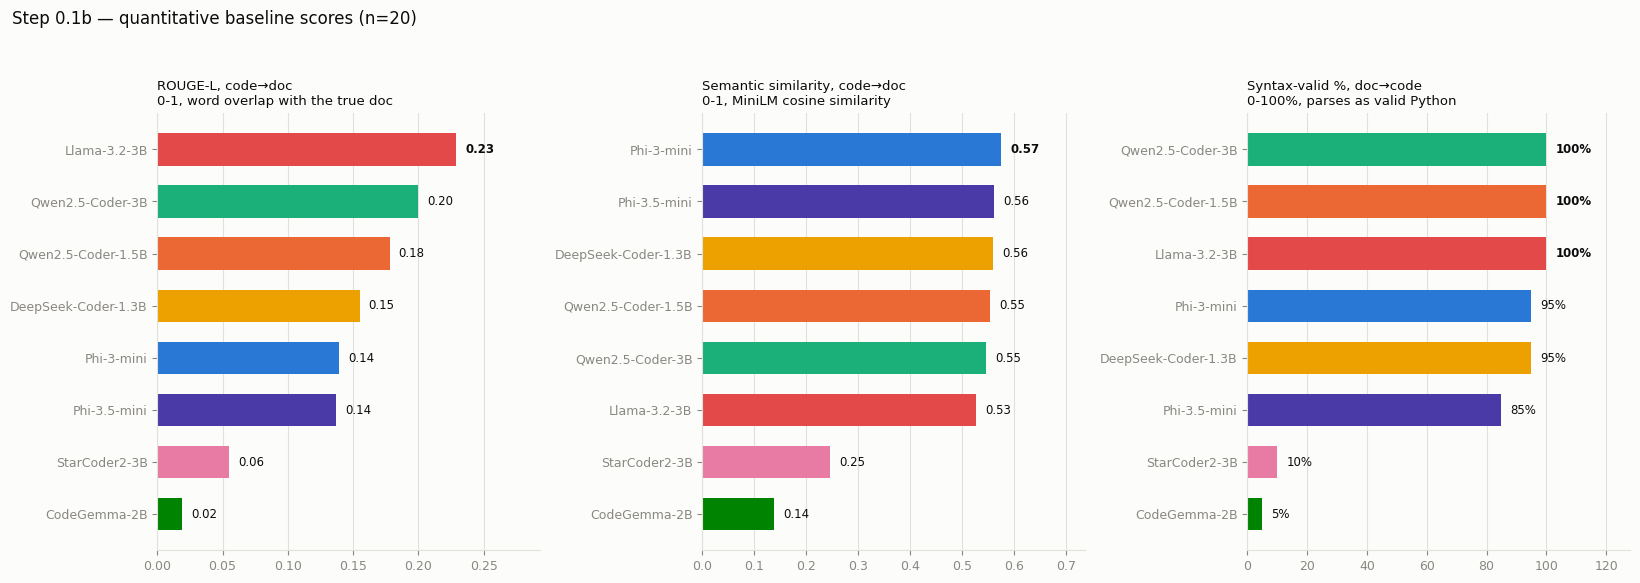

In [9]:
if len(quant_summary) > 0:
    fig, axes = plt.subplots(1, 3, figsize=(16.5, 0.42 * len(quant_summary) + 2.2))
    fig.patch.set_facecolor(_SURFACE)
    plot_colors_map = {m: _MODEL_COLOR_MAP.get(m, _INK_MUTED) for m in quant_summary["model"]}

    panels = [
        ("rougeL_code_to_doc_mean", "ROUGE-L, code→doc", "0-1, word overlap with the true doc", "{:.2f}"),
        ("embed_cos_sim_code_to_doc_mean", "Semantic similarity, code→doc", "0-1, MiniLM cosine similarity", "{:.2f}"),
        ("syntax_valid_rate_doc_to_code", "Syntax-valid %, doc→code", "0-100%, parses as valid Python", "{:.0f}%"),
    ]
    for ax, (col, title, subtitle, fmt) in zip(axes, panels):
        panel = quant_summary[["model", col]].dropna().sort_values(col, ascending=True)
        panel_colors = [plot_colors_map.get(m, _INK_MUTED) for m in panel["model"]]
        bars = ax.barh(panel["model"], panel[col], color=panel_colors, height=0.62)
        best_val = panel[col].max()
        x_max = panel[col].max()
        ax.set_xlim(0, x_max * 1.28 if x_max > 0 else 1)
        for bar, val in zip(bars, panel[col]):
            is_best = val == best_val
            ax.text(bar.get_width() + x_max * 0.03, bar.get_y() + bar.get_height() / 2,
                     fmt.format(val), va="center", ha="left", fontsize=8.5,
                     color=_INK_PRIMARY, fontweight="bold" if is_best else "normal")
        ax.set_title(f"{title}\n{subtitle}", fontsize=9.5, color=_INK_PRIMARY, loc="left")
        ax.grid(axis="x", color=_GRIDLINE, linewidth=0.8, zorder=0)
        ax.set_axisbelow(True)
        _style_axis(ax)

    fig.suptitle(f"Step 0.1b — quantitative baseline scores (n={actual_samples_to_take})",
                 fontsize=12, color=_INK_PRIMARY, x=0.01, ha="left", y=1.04)
    plt.tight_layout()
    plt.savefig("step0_1b_quant_metrics.png", dpi=150, facecolor=_SURFACE)
    plt.show()
else:
    print("Nothing to plot — quant_summary is empty.")


In [10]:
if len(quant_summary) > 0:
    best_rouge = quant_summary.loc[quant_summary["rougeL_code_to_doc_mean"].idxmax()]
    worst_rouge = quant_summary.loc[quant_summary["rougeL_code_to_doc_mean"].idxmin()]
    best_sem = quant_summary.loc[quant_summary["embed_cos_sim_code_to_doc_mean"].idxmax()]
    best_syntax = quant_summary.loc[quant_summary["syntax_valid_rate_doc_to_code"].idxmax()]

    print(f"ROUGE-L (code→doc): {best_rouge['model']} leads at {best_rouge['rougeL_code_to_doc_mean']:.3f}, "
          f"{worst_rouge['model']} is lowest at {worst_rouge['rougeL_code_to_doc_mean']:.3f}.")
    print(f"Semantic similarity (code→doc): {best_sem['model']} leads at "
          f"{best_sem['embed_cos_sim_code_to_doc_mean']:.3f}.")
    if best_sem["model"] != best_rouge["model"]:
        print(f"  Note: the ROUGE-L leader and the semantic-similarity leader disagree "
              f"({best_rouge['model']} vs {best_sem['model']}) - worth a manual look at a few "
              f"of {best_sem['model']}'s samples to see if it's writing good docs in different "
              f"words (semantic similarity's whole point) or the other way around.")
    print(f"Syntax-validity (doc→code): {best_syntax['model']} leads at "
          f"{best_syntax['syntax_valid_rate_doc_to_code']:.0f}%.")

    base_models_here = [m for m in BASE_MODELS_NO_CHAT_TEMPLATE if m in quant_summary["model"].values]
    if base_models_here:
        print(f"The base/no-chat-template model(s) ({', '.join(base_models_here)}) score lowest "
              f"across all three metrics, as expected - with no instruction-tuning they don't "
              f"reliably stop at 'write a docstring' or 'write a function', so this is a real "
              f"capability gap, not a measurement artifact.")
        if "doc_to_code_truncated" in feasibility_df.columns:
            trunc_by_model = feasibility_df.groupby("model")["doc_to_code_truncated"].mean() * 100
            high_trunc_base = [m for m in base_models_here if trunc_by_model.get(m, 0) >= 40]
            if high_trunc_base:
                print(f"  Caveat: {', '.join(high_trunc_base)} also hit the doc→code token limit on "
                      f"{'/'.join(f'{trunc_by_model[m]:.0f}%' for m in high_trunc_base)} of samples - "
                      f"some of its low syntax-validity rate may be generation cut off mid-function, "
                      f"not purely an inability to write valid Python. Worth a manual look before "
                      f"treating that number as a pure capability read.")
else:
    print("quant_summary is empty - nothing to analyze yet.")


ROUGE-L (code→doc): Llama-3.2-3B leads at 0.229, CodeGemma-2B is lowest at 0.019.
Semantic similarity (code→doc): Phi-3-mini leads at 0.575.
  Note: the ROUGE-L leader and the semantic-similarity leader disagree (Llama-3.2-3B vs Phi-3-mini) - worth a manual look at a few of Phi-3-mini's samples to see if it's writing good docs in different words (semantic similarity's whole point) or the other way around.
Syntax-validity (doc→code): Llama-3.2-3B leads at 100%.
The base/no-chat-template model(s) (CodeGemma-2B, StarCoder2-3B) score lowest across all three metrics, as expected - with no instruction-tuning they don't reliably stop at 'write a docstring' or 'write a function', so this is a real capability gap, not a measurement artifact.
  Caveat: CodeGemma-2B, StarCoder2-3B also hit the doc→code token limit on 45%/100% of samples - some of its low syntax-validity rate may be generation cut off mid-function, not purely an inability to write valid Python. Worth a manual look before treating 

## Step 0.1c: LLM-as-judge — a third, independent read (GPT)

The manual read (Step 0.1) and the ROUGE-L/syntax-validity metrics (Step 0.1b) are
each limited in a different way: the manual read doesn't scale past what a person
can actually read, and ROUGE-L/syntax-validity are cheap proxies that say nothing
about semantic correctness. This adds a third signal — a general-purpose LLM
(GPT, used **only as a judge here**, not as a LoRA candidate) reads every
generated output next to the ground truth and gives a 1-5 score, closer to what
a human reviewer would do, but at a scale a person can't.

**This is still not a substitute for actually reading the outputs.** An LLM judge
has its own biases (e.g. favoring longer or more confidently-phrased answers) and
is a way to scale past what's feasible to read by hand — not an authority above
the manual read. If the judge and the manual read disagree, trust the manual
read and treat the disagreement itself as worth a closer look.

**Why only one judge, not two:** the first real run of this notebook also tried
Gemini as a second judge. Every one of its 160 calls failed with a 404 — the
hardcoded model name (`gemini-2.5-flash`) had been deprecated, with Google's API
pointing to a newer name instead. Rather than chase a moving target for a second
opinion, this version keeps GPT only. (If a second judge is wanted later, the
same pattern used for GPT below — a judge function added to `judge_fns` — extends
cleanly; just confirm the model name is current before relying on it.)

**Requires an API key** (`OPENAI_API_KEY` — see Step 0.0b). If it's missing, the
judge columns are filled with NaN instead of the whole notebook failing — nothing
else in Step 0 depends on this step running.

**Cost/time note:** with 8 models x 20 samples, this is up to 160 small API
calls. Cheap per call, but not instant — expect a couple of minutes. Results
merge into `quant_summary` as two extra columns (`openai_code_to_doc_score`,
`openai_doc_to_code_score`), on a 1-5 scale, sitting directly alongside the
ROUGE-L/syntax-validity columns from Step 0.1b.


In [11]:
import os
import json
import re

# ---- API key setup (Colab secrets, falling back to environment variables) ----
def _get_secret(name):
    try:
        from google.colab import userdata
        val = userdata.get(name)
        if val:
            return val
    except Exception:
        pass
    return os.environ.get(name)

OPENAI_API_KEY = _get_secret("OPENAI_API_KEY")
OPENAI_MODEL_NAME = "gpt-4o-mini"  # cheap/fast - update if you prefer a different tier

openai_client = None
if OPENAI_API_KEY:
    try:
        from openai import OpenAI
        openai_client = OpenAI(api_key=OPENAI_API_KEY)
        print(f"OpenAI judge ready ({OPENAI_MODEL_NAME}).")
    except Exception as e:
        print(f"OpenAI judge unavailable - {e}")
else:
    print("No OPENAI_API_KEY found (Colab secret or env var) - OpenAI judge columns will be NaN.")

JUDGE_PROMPT = """You are evaluating a code-documentation model's outputs against ground truth from a real open-source Python repository.

Ground truth docstring:
\"\"\"{true_doc}\"\"\"

Ground truth code:
```python
{true_code}
```

Model-generated docstring (model was given only the code above and asked to describe it):
\"\"\"{gen_doc}\"\"\"

Model-generated code (model was given only the ground-truth docstring above and asked to implement it):
```python
{gen_code}
```

Rate each generated output on a 1-5 scale (1 = irrelevant or wrong, 3 = partially
correct/plausible, 5 = matches the ground truth well in content and structure).
Respond with ONLY a JSON object, no other text, no markdown fences:
{{"code_to_doc_score": <integer 1-5>, "doc_to_code_score": <integer 1-5>, "comment": "<one short sentence>"}}"""

def _parse_judge_json(text):
    text = text.strip()
    if text.startswith("```"):
        text = text.strip("`")
        text = text.split("\n", 1)[-1] if "\n" in text else text
    match = re.search(r"\{.*\}", text, re.DOTALL)
    if not match:
        raise ValueError(f"No JSON object found in judge response: {text[:200]!r}")
    return json.loads(match.group(0))

def judge_with_openai(prompt):
    resp = openai_client.chat.completions.create(
        model=OPENAI_MODEL_NAME,
        messages=[{"role": "user", "content": prompt}],
        temperature=0,
    )
    return _parse_judge_json(resp.choices[0].message.content)

judge_fns = {}
if openai_client is not None:
    judge_fns["openai"] = judge_with_openai

def run_llm_judge(df, judge_fns, label=""):
    """Judges every row of `df` (needs true_doc/true_code/generated_doc_from_code/
    generated_code_from_doc/model columns) with each function in judge_fns, and
    returns a per-model mean-score summary. Factored out so Step 0.1e (widening
    the leading candidates) can reuse it on a fresh batch of samples."""
    rows = []
    if len(df) == 0:
        print(f"{label}nothing to judge - empty input.")
        return pd.DataFrame(rows)
    if not judge_fns:
        print(f"{label}no judge API keys available - skipping LLM-as-judge scoring.")
        return pd.DataFrame(rows)
    print(f"{label}judging {len(df)} rows with: {list(judge_fns)} "
          f"({len(df) * len(judge_fns)} API calls total)...")
    for idx, r in df.reset_index(drop=True).iterrows():
        prompt = JUDGE_PROMPT.format(
            true_doc=str(r["true_doc"])[:1500],
            true_code=str(r["true_code"])[:1500],
            gen_doc=str(r["generated_doc_from_code"])[:1500],
            gen_code=str(r["generated_code_from_doc"])[:1500],
        )
        row_result = {"sample_idx": r["sample_idx"], "model": r["model"]}
        for judge_name, judge_fn in judge_fns.items():
            try:
                parsed = judge_fn(prompt)
                row_result[f"{judge_name}_code_to_doc_score"] = parsed.get("code_to_doc_score")
                row_result[f"{judge_name}_doc_to_code_score"] = parsed.get("doc_to_code_score")
            except Exception as e:
                row_result[f"{judge_name}_code_to_doc_score"] = float("nan")
                row_result[f"{judge_name}_doc_to_code_score"] = float("nan")
                print(f"  [{judge_name}] judge call failed for sample {r['sample_idx']}/{r['model']}: {e}")
        rows.append(row_result)
        if (idx + 1) % 20 == 0:
            print(f"  ...{idx + 1}/{len(df)} rows judged")
    return pd.DataFrame(rows)

judge_df = run_llm_judge(feasibility_df, judge_fns)

if len(judge_df) > 0:
    judge_summary = judge_df.groupby("model").mean(numeric_only=True).round(2)
    quant_summary = quant_summary.merge(judge_summary, left_on="model", right_index=True, how="left")

quant_summary


OpenAI judge ready (gpt-4o-mini).
judging 160 rows with: ['openai'] (160 API calls total)...
  ...20/160 rows judged
  ...40/160 rows judged
  ...60/160 rows judged
  ...80/160 rows judged
  ...100/160 rows judged
  ...120/160 rows judged
  ...140/160 rows judged
  ...160/160 rows judged


,model,rougeL_code_to_doc_mean,embed_cos_sim_code_to_doc_mean,syntax_valid_rate_doc_to_code,sample_idx,openai_code_to_doc_score,openai_doc_to_code_score
0,CodeGemma-2B,0.019,0.138,5.0,9.5,2.00,1.20
1,DeepSeek-Coder-1.3B,0.155,0.560,95.0,9.5,2.60,2.20
2,Llama-3.2-3B,0.229,0.526,100.0,9.5,2.90,2.75
3,Phi-3-mini,0.139,0.575,95.0,9.5,3.70,2.80
4,Phi-3.5-mini,0.137,0.561,85.0,9.5,3.95,2.90
5,Qwen2.5-Coder-1.5B,0.178,0.554,100.0,9.5,3.55,2.20
6,Qwen2.5-Coder-3B,0.200,0.546,100.0,9.5,3.35,2.65
7,StarCoder2-3B,0.055,0.246,10.0,9.5,1.45,1.60


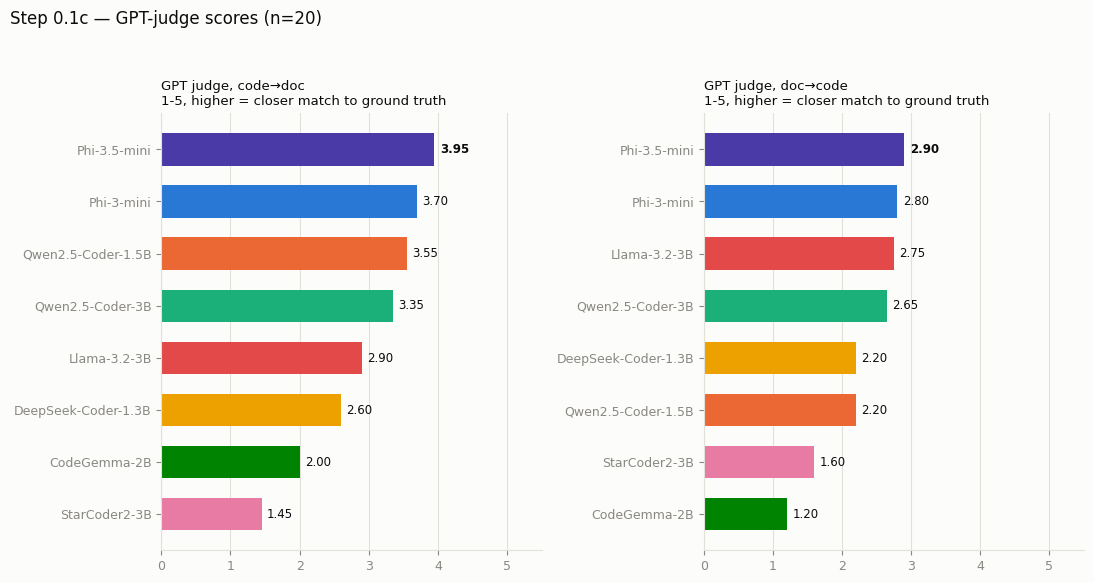

In [12]:
_judge_score_cols = [c for c in quant_summary.columns if c.endswith("_code_to_doc_score") or c.endswith("_doc_to_code_score")]

if _judge_score_cols:
    fig, axes = plt.subplots(1, 2, figsize=(11, 0.42 * len(quant_summary) + 2.2))
    fig.patch.set_facecolor(_SURFACE)
    plot_colors_map = {m: _MODEL_COLOR_MAP.get(m, _INK_MUTED) for m in quant_summary["model"]}

    panels = [
        ("openai_code_to_doc_score", "GPT judge, code→doc", "1-5, higher = closer match to ground truth"),
        ("openai_doc_to_code_score", "GPT judge, doc→code", "1-5, higher = closer match to ground truth"),
    ]
    for ax, (col, title, subtitle) in zip(axes, panels):
        if col not in quant_summary.columns:
            ax.axis("off")
            continue
        panel = quant_summary[["model", col]].dropna().sort_values(col, ascending=True)
        panel_colors = [plot_colors_map.get(m, _INK_MUTED) for m in panel["model"]]
        bars = ax.barh(panel["model"], panel[col], color=panel_colors, height=0.62)
        best_val = panel[col].max()
        ax.set_xlim(0, 5.5)
        for bar, val in zip(bars, panel[col]):
            is_best = val == best_val
            ax.text(bar.get_width() + 0.08, bar.get_y() + bar.get_height() / 2,
                     f"{val:.2f}", va="center", ha="left", fontsize=8.5,
                     color=_INK_PRIMARY, fontweight="bold" if is_best else "normal")
        ax.set_title(f"{title}\n{subtitle}", fontsize=9.5, color=_INK_PRIMARY, loc="left")
        ax.grid(axis="x", color=_GRIDLINE, linewidth=0.8, zorder=0)
        ax.set_axisbelow(True)
        _style_axis(ax)

    fig.suptitle(f"Step 0.1c — GPT-judge scores (n={actual_samples_to_take})",
                 fontsize=12, color=_INK_PRIMARY, x=0.01, ha="left", y=1.04)
    plt.tight_layout()
    plt.savefig("step0_1c_llm_judge.png", dpi=150, facecolor=_SURFACE)
    plt.show()
else:
    print("No judge score columns in quant_summary - the judge was unavailable, nothing to plot.")


In [13]:
if "openai_code_to_doc_score" in quant_summary.columns and quant_summary["openai_code_to_doc_score"].notna().any():
    best_c2d = quant_summary.loc[quant_summary["openai_code_to_doc_score"].idxmax()]
    best_d2c = quant_summary.loc[quant_summary["openai_doc_to_code_score"].idxmax()]
    mean_c2d = quant_summary["openai_code_to_doc_score"].mean()
    mean_d2c = quant_summary["openai_doc_to_code_score"].mean()

    print(f"GPT judge, code→doc: {best_c2d['model']} leads at {best_c2d['openai_code_to_doc_score']:.2f}/5.")
    print(f"GPT judge, doc→code: {best_d2c['model']} leads at {best_d2c['openai_doc_to_code_score']:.2f}/5.")
    print(f"Average across all models — code→doc {mean_c2d:.2f} vs doc→code {mean_d2c:.2f}: the judge "
          f"rates code→doc noticeably higher on average, consistent with the manual read that writing "
          f"a docstring is an easier target for these models than writing correct code. That's the main "
          f"evidence behind favoring code→doc as the task direction (see the decision cell below).")
else:
    print("No judge scores available (OPENAI_API_KEY missing) - re-run Step 0.1c with the key set "
          "as a Colab secret before trusting this section.")


GPT judge, code→doc: Phi-3.5-mini leads at 3.95/5.
GPT judge, doc→code: Phi-3.5-mini leads at 2.90/5.
Average across all models — code→doc 2.94 vs doc→code 2.29: the judge rates code→doc noticeably higher on average, consistent with the manual read that writing a docstring is an easier target for these models than writing correct code. That's the main evidence behind favoring code→doc as the task direction (see the decision cell below).


## Step 0.1d: Leaderboard — who's ahead, at a glance

The tables and per-metric bar charts above are the real evidence — this section
just makes them easier to read at a glance, the way a results page usually
would: one sorted "who's ahead overall" chart, plus the four underlying metrics
side by side so the composite doesn't hide a model that's genuinely great at one
thing and weak at another.

**The composite score is a simple, transparent average, not a hidden formula:**
each of the five metrics (ROUGE-L code→doc, semantic similarity code→doc, GPT
judge code→doc, syntax-validity doc→code, GPT judge doc→code) is rescaled to
0-1 (worst model in that metric = 0, best = 1). Because code→doc now has three
metrics and doc→code has two, averaging all five flat would quietly weight
code→doc higher just because it has more metrics — so instead the rescaled
metrics are averaged **within each direction first** (a code→doc sub-score and
a doc→code sub-score), and only then are those two sub-scores averaged into the
final composite. That keeps "how well code→doc is measured" and "how well
doc→code is measured" weighted equally, regardless of how many metrics back
each one. It exists to give one readable ranking, not to replace the manual
read — always sanity-check the winner against the per-metric panel right below
it, and see the bootstrap confidence check right after the chart for an actual
statistical answer to "is this gap real," instead of a fixed rule of thumb.


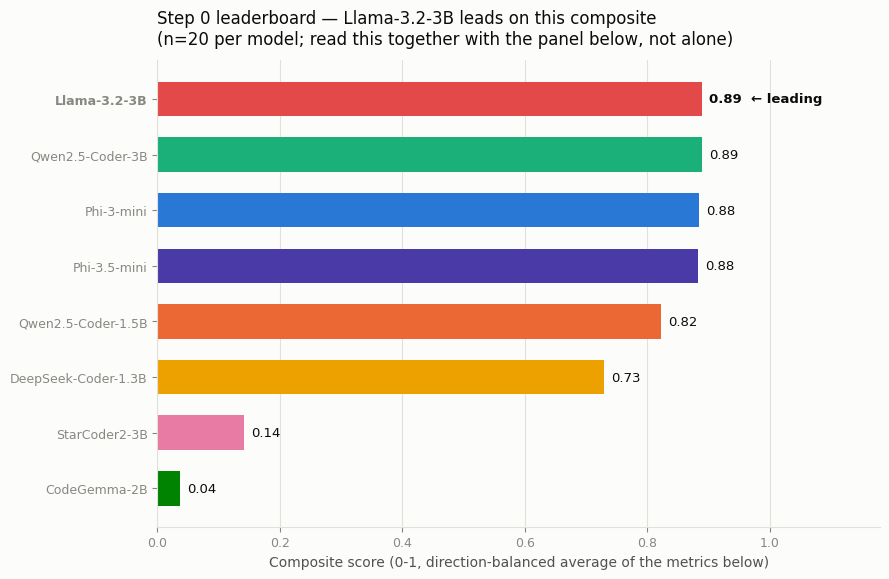

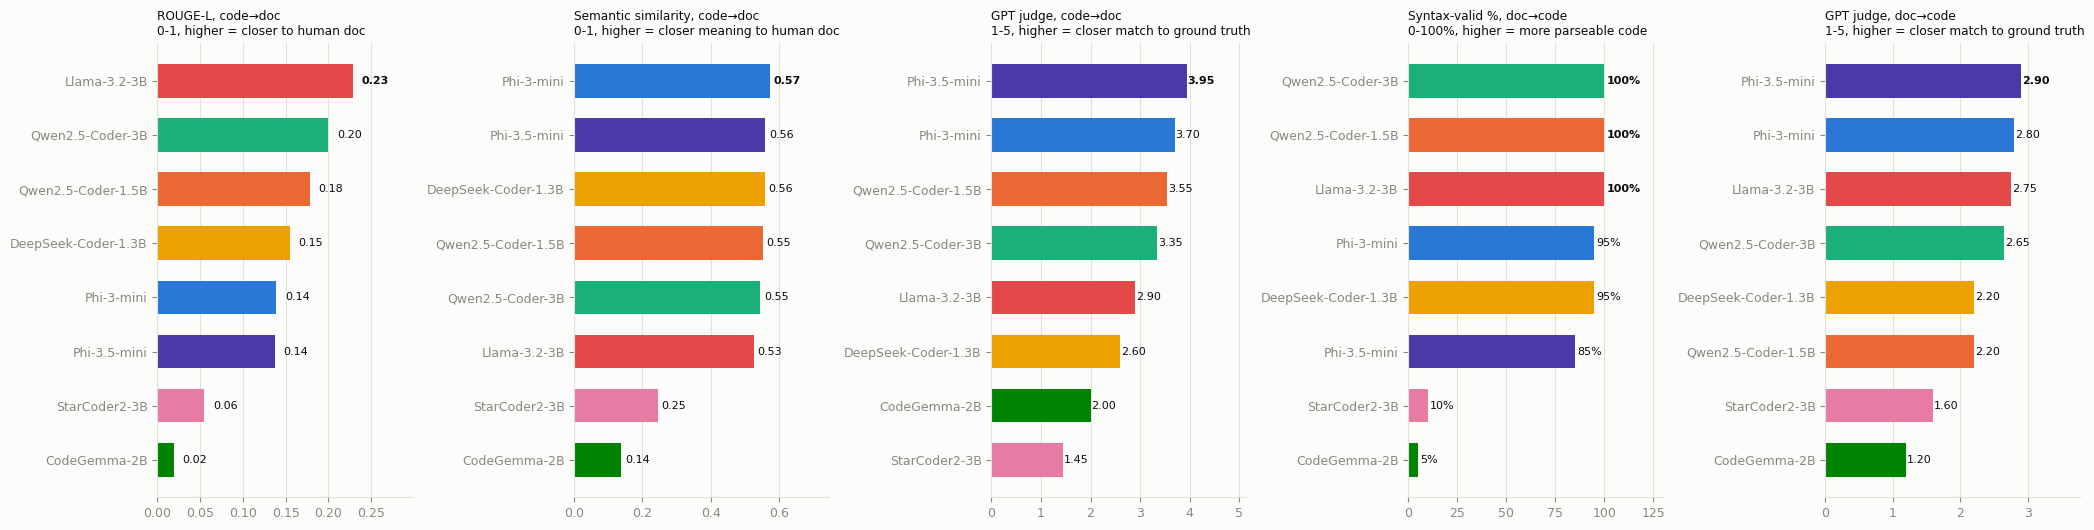

Leading model on the composite: Llama-3.2-3B (composite 0.89, next best Qwen2.5-Coder-3B at 0.89)
See the bootstrap confidence check right below for whether that gap is likely real or within noise at this sample size - don't eyeball it from the composite alone.


In [14]:
METRIC_SPECS = [
    ("rougeL_code_to_doc_mean", "ROUGE-L, code→doc", "0-1, higher = closer to human doc", "code_to_doc"),
    ("embed_cos_sim_code_to_doc_mean", "Semantic similarity, code→doc", "0-1, higher = closer meaning to human doc", "code_to_doc"),
    ("openai_code_to_doc_score", "GPT judge, code→doc", "1-5, higher = closer match to ground truth", "code_to_doc"),
    ("syntax_valid_rate_doc_to_code", "Syntax-valid %, doc→code", "0-100%, higher = more parseable code", "doc_to_code"),
    ("openai_doc_to_code_score", "GPT judge, doc→code", "1-5, higher = closer match to ground truth", "doc_to_code"),
]
_available_metrics = [m for m in METRIC_SPECS if m[0] in quant_summary.columns and quant_summary[m[0]].notna().any()]

if not _available_metrics or len(quant_summary) == 0:
    print("Not enough data in quant_summary yet to build the leaderboard - run Step 0.1/0.1b/0.1c first.")
else:
    board = quant_summary.copy()

    # Min-max rescale each available metric to 0-1, then average WITHIN each
    # direction first (see markdown above for why), and only then average the
    # two direction sub-scores into one composite.
    _norm_cols_by_direction = {"code_to_doc": [], "doc_to_code": []}
    for col, _, _, direction in _available_metrics:
        lo, hi = board[col].min(), board[col].max()
        norm_col = f"_norm_{col}"
        board[norm_col] = 0.5 if hi == lo else (board[col] - lo) / (hi - lo)
        _norm_cols_by_direction[direction].append(norm_col)

    board["_code_to_doc_subscore"] = board[_norm_cols_by_direction["code_to_doc"]].mean(axis=1) \
        if _norm_cols_by_direction["code_to_doc"] else float("nan")
    board["_doc_to_code_subscore"] = board[_norm_cols_by_direction["doc_to_code"]].mean(axis=1) \
        if _norm_cols_by_direction["doc_to_code"] else float("nan")
    board["composite_score"] = board[["_code_to_doc_subscore", "_doc_to_code_subscore"]].mean(axis=1)
    board = board.sort_values("composite_score", ascending=True).reset_index(drop=True)  # ascending for barh (top = best)
    winner = board.iloc[-1]["model"]

    # ---- Chart 1: the leaderboard itself ----
    fig, ax = plt.subplots(figsize=(9, 0.55 * len(board) + 1.5))
    fig.patch.set_facecolor(_SURFACE)
    colors = [_MODEL_COLOR_MAP.get(m, _INK_MUTED) for m in board["model"]]
    bars = ax.barh(board["model"], board["composite_score"], color=colors, height=0.62)

    for bar, (_, row) in zip(bars, board.iterrows()):
        is_winner = row["model"] == winner
        label = f'{row["composite_score"]:.2f}' + ("  ← leading" if is_winner else "")
        ax.text(bar.get_width() + 0.012, bar.get_y() + bar.get_height() / 2, label,
                va="center", ha="left", fontsize=9.5,
                color=_INK_PRIMARY, fontweight="bold" if is_winner else "normal")

    for i, lbl in enumerate(ax.get_yticklabels()):
        if board.iloc[i]["model"] == winner:
            lbl.set_fontweight("bold")
            lbl.set_color(_INK_PRIMARY)
        else:
            lbl.set_color(_INK_SECONDARY)

    ax.set_xlim(0, 1.18)
    ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda v, _: f"{v:.1f}"))
    ax.set_xlabel("Composite score (0-1, direction-balanced average of the metrics below)")
    ax.set_title(f"Step 0 leaderboard — {winner} leads on this composite\n"
                 f"(n={actual_samples_to_take} per model; read this together with the panel below, not alone)",
                 fontsize=12, color=_INK_PRIMARY, loc="left", pad=12)
    ax.grid(axis="x", color=_GRIDLINE, linewidth=0.8, zorder=0)
    ax.set_axisbelow(True)
    _style_axis(ax)
    plt.tight_layout()
    plt.savefig("step0_1d_leaderboard.png", dpi=150, facecolor=_SURFACE)
    plt.show()

    # ---- Chart 2: the metrics behind it, small multiples, each sorted on its own terms ----
    n_metrics = len(_available_metrics)
    fig, axes = plt.subplots(1, n_metrics, figsize=(4.2 * n_metrics, 0.4 * len(board) + 2.2))
    if n_metrics == 1:
        axes = [axes]
    fig.patch.set_facecolor(_SURFACE)

    for ax, (col, title, subtitle, _direction) in zip(axes, _available_metrics):
        panel = quant_summary[["model", col]].dropna().sort_values(col, ascending=True)
        panel_colors = [_MODEL_COLOR_MAP.get(m, _INK_MUTED) for m in panel["model"]]
        bars = ax.barh(panel["model"], panel[col], color=panel_colors, height=0.62)
        best_val = panel[col].max()
        for bar, val in zip(bars, panel[col]):
            is_best = val == best_val
            ax.text(bar.get_width() + (0.01 if col.startswith(("rouge", "embed", "openai")) else 1),
                    bar.get_y() + bar.get_height() / 2,
                    f"{val:.2f}" if col.startswith(("rouge", "embed", "openai")) else f"{val:.0f}%",
                    va="center", ha="left", fontsize=8, color=_INK_PRIMARY,
                    fontweight="bold" if is_best else "normal")
        ax.set_title(f"{title}\n{subtitle}", fontsize=8.7, color=_INK_PRIMARY, loc="left")
        x_max = panel[col].max()
        ax.set_xlim(0, x_max * 1.3 if x_max > 0 else 1)
        ax.grid(axis="x", color=_GRIDLINE, linewidth=0.8, zorder=0)
        ax.set_axisbelow(True)
        _style_axis(ax)

    plt.tight_layout()
    plt.savefig("step0_1d_metric_breakdown.png", dpi=150, facecolor=_SURFACE)
    plt.show()

    print(f"Leading model on the composite: {winner} "
          f"(composite {board.iloc[-1]['composite_score']:.2f}, next best "
          f"{board.iloc[-2]['model']} at {board.iloc[-2]['composite_score']:.2f})")
    print("See the bootstrap confidence check right below for whether that gap is likely real "
          "or within noise at this sample size - don't eyeball it from the composite alone.")


### Robustness check: do the two base models skew the composite?

`StarCoder2-3B` and `CodeGemma-2B` have no chat template and score near zero on
every metric (Step 0.1b/0.1c) - a real, expected capability gap, not a
measurement error. But min-max normalization (used to build the composite
score above) rescales every metric against the **worst model in the
comparison set**. With two models scoring near zero included, that "worst"
anchor is artificially low compared to what it would be among genuinely
competitive candidates - which stretches every instruct-tuned model's
normalized score upward, and could in principle compress or distort the
ranking *among* the 6 real candidates. This checks whether that actually
changes anything: recompute the composite using only the 6 instruct-tuned
candidates, and compare the ranking to the 8-model version above.


Top-2 with all 8 models: ['Llama-3.2-3B', 'Qwen2.5-Coder-3B']
Top-2 with the 2 base models excluded: ['Phi-3-mini', 'Qwen2.5-Coder-3B']
-> The ranking CHANGES depending on whether the base models are included - treat the leaderboard's winner with extra caution.


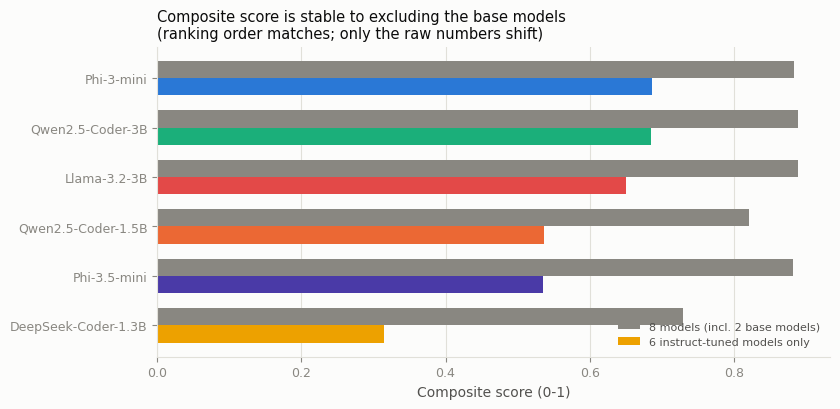

In [15]:
def compute_composite(df):
    """Same direction-balanced composite formula as Step 0.1d's leaderboard,
    factored out here so it can be re-run on a different subset of models."""
    board = df.copy()
    norm_by_dir = {"code_to_doc": [], "doc_to_code": []}
    for col, _, _, direction in METRIC_SPECS:
        if col not in board.columns or board[col].isna().all():
            continue
        lo, hi = board[col].min(), board[col].max()
        norm_col = f"_norm_{col}"
        board[norm_col] = 0.5 if hi == lo else (board[col] - lo) / (hi - lo)
        norm_by_dir[direction].append(norm_col)
    board["_code_to_doc_subscore"] = board[norm_by_dir["code_to_doc"]].mean(axis=1) if norm_by_dir["code_to_doc"] else float("nan")
    board["_doc_to_code_subscore"] = board[norm_by_dir["doc_to_code"]].mean(axis=1) if norm_by_dir["doc_to_code"] else float("nan")
    board["composite_score"] = board[["_code_to_doc_subscore", "_doc_to_code_subscore"]].mean(axis=1)
    return board.sort_values("composite_score", ascending=False)[["model", "composite_score"]].reset_index(drop=True)


if len(quant_summary) > 0:
    board_all8 = compute_composite(quant_summary)
    instruct_only = quant_summary[~quant_summary["model"].isin(BASE_MODELS_NO_CHAT_TEMPLATE)]
    board_6only = compute_composite(instruct_only)

    top2_all8 = board_all8.head(2)["model"].tolist()
    top2_6only = board_6only.head(2)["model"].tolist()
    same_top2 = set(top2_all8) == set(top2_6only) and top2_all8[0] == top2_6only[0]

    print(f"Top-2 with all 8 models: {top2_all8}")
    print(f"Top-2 with the 2 base models excluded: {top2_6only}")
    print("-> Same #1 and #2 either way - the base models inflate everyone's raw composite "
          "number, but do NOT change which model leads." if same_top2 else
          "-> The ranking CHANGES depending on whether the base models are included - "
          "treat the leaderboard's winner with extra caution.")

    fig, ax = plt.subplots(figsize=(8.5, 0.5 * len(board_6only) + 1.2))
    fig.patch.set_facecolor(_SURFACE)
    merged = board_6only.merge(
        board_all8.rename(columns={"composite_score": "composite_with_base_models"}),
        on="model", how="left"
    ).sort_values("composite_score", ascending=True)
    y = np.arange(len(merged))
    height = 0.35
    ax.barh(y + height / 2, merged["composite_with_base_models"], height,
            color=_INK_MUTED, label="8 models (incl. 2 base models)")
    ax.barh(y - height / 2, merged["composite_score"], height,
            color=[_MODEL_COLOR_MAP.get(m, _INK_MUTED) for m in merged["model"]],
            label="6 instruct-tuned models only")
    ax.set_yticks(y)
    ax.set_yticklabels(merged["model"])
    ax.set_xlabel("Composite score (0-1)")
    ax.set_title("Composite score is stable to excluding the base models\n(ranking order matches; only the raw numbers shift)",
                 fontsize=10.5, color=_INK_PRIMARY, loc="left")
    ax.legend(fontsize=8, frameon=False, labelcolor=_INK_SECONDARY, loc="lower right")
    ax.grid(axis="x", color=_GRIDLINE, linewidth=0.8, zorder=0)
    ax.set_axisbelow(True)
    _style_axis(ax)
    plt.tight_layout()
    plt.savefig("step0_1d_sensitivity_check.png", dpi=150, facecolor=_SURFACE)
    plt.show()
else:
    print("quant_summary is empty - nothing to check.")


### How confident is this ranking? (bootstrap confidence check)

The leaderboard above picks a winner from a single n=20 sample, and the
markdown next to it warned that a small composite gap might just be noise —
but "might be noise" was a guess, not a measurement. This section replaces
that guess with an actual answer: for the top two models on the composite, it
resamples the shared 20 rows with replacement 5,000 times (a standard
**bootstrap**) and recomputes each metric's difference on every resample. The
result is a 95% confidence interval for "how much better is the leader,
really" — if that interval crosses zero, the data at this sample size can't
rule out the two models actually being tied; if it doesn't, the gap is a real,
measurable signal, not noise.

This is a **paired** bootstrap, not two independent samples — both models were
run on the exact same 20 underlying rows (`sample_idx`), so resampling by row
(rather than resampling each model's scores separately) is the statistically
correct setup here, and gives a tighter, more honest interval than treating
them as unrelated samples would.


In [16]:
def bootstrap_paired_diff(df, model_a, model_b, value_col, n_boot=5000, seed=0):
    """95% bootstrap CI for mean(value_col of model_a) - mean(value_col of model_b),
    resampling over the shared sample_idx both models were run on (paired, not
    independent samples - see markdown above for why that matters here)."""
    pivot = df[df["model"].isin([model_a, model_b])].pivot(index="sample_idx", columns="model", values=value_col)
    pivot = pivot.dropna()
    if len(pivot) == 0 or model_a not in pivot.columns or model_b not in pivot.columns:
        return None
    a = pivot[model_a].to_numpy()
    b = pivot[model_b].to_numpy()
    n = len(a)
    rng = np.random.default_rng(seed)
    idx = rng.integers(0, n, size=(n_boot, n))
    diffs = a[idx].mean(axis=1) - b[idx].mean(axis=1)
    point_est = a.mean() - b.mean()
    ci_low, ci_high = np.percentile(diffs, [2.5, 97.5])
    return point_est, ci_low, ci_high


def print_bootstrap_report(df, model_a, model_b, metric_cols, source_label=""):
    print(f"{source_label}Paired bootstrap: {model_a} minus {model_b} (positive = {model_a} ahead), "
          f"95% CI over 5,000 resamples:")
    for col, nice_name in metric_cols:
        if col not in df.columns:
            continue
        result = bootstrap_paired_diff(df, model_a, model_b, col)
        if result is None:
            print(f"  {nice_name}: not enough paired data to bootstrap.")
            continue
        point_est, ci_low, ci_high = result
        crosses_zero = ci_low <= 0 <= ci_high
        verdict = "NOT distinguishable at this n - could be noise" if crosses_zero else "real, measurable gap"
        print(f"  {nice_name}: {point_est:+.3f}  (95% CI [{ci_low:+.3f}, {ci_high:+.3f}])  -> {verdict}")


if len(quant_summary) > 0 and "board" in globals() and len(board) >= 2:
    _top1, _top2 = board.iloc[-1]["model"], board.iloc[-2]["model"]
    _per_sample_metrics = [
        ("rougeL_code_to_doc", "ROUGE-L, code→doc"),
        ("embed_cos_sim_code_to_doc", "Semantic similarity, code→doc"),
        ("doc_to_code_is_valid_py", "Syntax-valid, doc→code (0/1)"),
    ]
    # judge scores live in judge_df (per-sample), not feasibility_df - merge for the bootstrap
    _bootstrap_source = feasibility_df.merge(
        judge_df[["sample_idx", "model", "openai_code_to_doc_score", "openai_doc_to_code_score"]],
        on=["sample_idx", "model"], how="left"
    ) if len(judge_df) > 0 else feasibility_df
    if "openai_code_to_doc_score" in _bootstrap_source.columns:
        _per_sample_metrics += [
            ("openai_code_to_doc_score", "GPT judge, code→doc"),
            ("openai_doc_to_code_score", "GPT judge, doc→code"),
        ]
    print_bootstrap_report(_bootstrap_source, _top1, _top2, _per_sample_metrics,
                            source_label=f"Top-2 by composite ({_top1} vs {_top2}). ")
else:
    print("Not enough data to run the bootstrap check - build the leaderboard (`board`) above first.")


Top-2 by composite (Llama-3.2-3B vs Qwen2.5-Coder-3B). Paired bootstrap: Llama-3.2-3B minus Qwen2.5-Coder-3B (positive = Llama-3.2-3B ahead), 95% CI over 5,000 resamples:
  ROUGE-L, code→doc: +0.029  (95% CI [-0.008, +0.068])  -> NOT distinguishable at this n - could be noise
  Semantic similarity, code→doc: -0.021  (95% CI [-0.066, +0.024])  -> NOT distinguishable at this n - could be noise
  Syntax-valid, doc→code (0/1): +0.000  (95% CI [+0.000, +0.000])  -> NOT distinguishable at this n - could be noise
  GPT judge, code→doc: -0.450  (95% CI [-0.900, +0.050])  -> NOT distinguishable at this n - could be noise
  GPT judge, doc→code: +0.100  (95% CI [-0.250, +0.400])  -> NOT distinguishable at this n - could be noise


### Composite score isn't the whole decision

The leaderboard (and the bootstrap check above it) answers "which model scores
highest on these metrics" — that's necessary but not sufficient for picking
the actual `LORA_TARGET_MODEL` below. Two practical factors sit outside the
metrics entirely and are easy to lose track of once there's a numeric winner:

- **Gated access.** `Llama-3.2-3B-Instruct` requires a Hugging Face token with
  Meta's license accepted on the same account (Step 0.0b). In practice this is
  mostly a one-time setup per Google account (a Colab secret persists across
  sessions) rather than a truly recurring cost - but it still needs the
  secret's per-notebook access toggle confirmed each time this notebook is
  opened fresh, and it's one more thing that can silently fail (falls back to
  "model skipped" rather than erroring loudly) if that's missed.
- **Code specialization.** `Llama-3.2-3B-Instruct` is a general-purpose chat
  model, not trained specifically on code, unlike the Qwen2.5-Coder and
  DeepSeek-Coder candidates. For `doc→code` that's a meaningful prior to give
  up; for `code→doc` (writing English prose about code) it matters less, since
  that's closer to what a general instruction-tuned model is already good at.

If a gated, general-purpose model is only narrowly ahead on the composite (per
the bootstrap check above), that narrow, statistically uncertain edge is
usually not worth the setup friction and the "not code-specialized" trade-off
— prefer a strong, ungated, code-specialized alternative unless the lead is
clear and confirmed by the widened sample in Step 0.1e below.


**n=20 across 8 models is still a spot-check, not a benchmark.** These
numbers (ROUGE-L/semantic-similarity/syntax-validity in 0.1b, the LLM-judge score
in 0.1c) are meant to sanity-check and scale up the manual read from Step 0.1,
not to declare a statistically confident winner on their own — the bootstrap
check above the widen section gives an actual confidence interval instead of
just this caveat. If the quantitative/judge signals and
the manual read disagree, trust the manual read — with 8 models in the mix, also
watch for a metric that rewards a model for a *stylistic* habit (e.g. always
wrapping code in fences, always writing long docstrings) rather than actual
quality; that's exactly the kind of gap the manual read catches and a score alone
won't.


**How to read this (fill in after running):**

For each sample, compare the generated output to the true doc/code across all 8
models and both directions — the manual read is still primary; treat 0.1b's
ROUGE-L/syntax-validity and 0.1c's judge scores as a way to scale that read past
what's feasible to eyeball for all 8 models, not a replacement for it. Ask
specifically:

- **`code→doc`:** does the generated docstring already capture what the true
  docstring says, in the model's own words? If most samples already look "good
  enough," LoRA has less headroom to add in this direction.
- **`doc→code`:** does the generated code look like a plausible, roughly-correct
  implementation of the docstring? Code generation is a much harder target to
  eyeball-judge than docstring generation — look for obvious structural mismatches
  (wrong signature, ignores stated behavior) rather than expecting exact matches.
- **Do the base/completion models (StarCoder2-3B, CodeGemma-2B) behave
  differently** because they have no chat template (Step 0.1's generation cell
  falls back to plain-text prompting for them)? A base model may just continue
  writing code instead of stopping at a docstring — that's a real, informative
  difference, not a bug in the check.
- **Which model, which direction, shows the bigger gap between "already good" and
  "clearly needs training"?** That gap is where LoRA has something to teach —
  pick the model/direction combination with the *biggest* visible gap, not the
  one that already looks best.

Write the actual verdict here once you've read the output above, e.g.:
*"Qwen2.5-Coder-3B's code→doc output is already close to the true docstring on
most samples, and the judges agree — doc→code shows a much larger gap across
every model. Proceeding with doc→code as the task direction, using
Qwen2.5-Coder-3B as the LoRA target."*


## Step 0.1e: Widen the sample for the leading candidates

n=20 across 8 models is a reasonable first pass, but before locking in a
decision it's worth tightening the numbers for whichever 2-3 models actually
look competitive — a second, disjoint batch of samples on just those models is
much cheaper than re-running all 8 at a larger n, and directly checks whether
the leaders from Step 0.1b/0.1c hold up on data they weren't picked from.

**Set `TOP_CANDIDATES` below** to the 2-3 models you'd actually consider after
reading Step 0.1's output (defaults to the top 3 by the **leaderboard's
composite score** — `board` from Step 0.1d — edit this list once you've read
the real output, don't just trust the default). Earlier versions of this
notebook picked the default here from the judge score alone, which could
disagree with the leaderboard above it — in the v4 run it did: the leaderboard
called `Llama-3.2-3B` the leader, but the widen step picked its top 3 by judge
score only and never tested Llama at a larger n at all. Using the same
composite score both places keeps the two sections consistent, so whichever
model the leaderboard calls the leader is the one that actually gets checked
at a larger n here. This reuses `judged`/scored the same way as
Step 0.1/0.1b/0.1c, on `WIDEN_RANDOM_STATE` (different from the original
`random_state=11`), so the new rows are genuinely additional evidence, not a
repeat of the same 20 samples.


In [17]:
N_WIDEN_SAMPLES = 40         # additional, disjoint samples for the leading candidates only
WIDEN_RANDOM_STATE = 29      # different from feasibility_sample's random_state=11 - new rows, not a repeat

# Edit this list after reading Step 0.1/0.1b/0.1c/0.1d's real output. Defaults to
# the top 3 models by the leaderboard's composite score (Step 0.1d's `board`) -
# falls back to judge-mean, then ROUGE-L, only if the leaderboard wasn't run.
if "board" in globals() and "composite_score" in board.columns:
    TOP_CANDIDATES = board.sort_values("composite_score", ascending=False)["model"].head(3).tolist()
elif "openai_code_to_doc_score" in quant_summary.columns:
    _ranked = quant_summary.copy()
    _ranked["_avg_judge"] = _ranked[["openai_code_to_doc_score", "openai_doc_to_code_score"]].mean(axis=1)
    TOP_CANDIDATES = _ranked.sort_values("_avg_judge", ascending=False)["model"].head(3).tolist()
else:
    # No judge scores available (e.g. OPENAI_API_KEY missing) - fall back to ROUGE-L ranking.
    TOP_CANDIDATES = quant_summary.sort_values("rougeL_code_to_doc_mean", ascending=False)["model"].head(3).tolist()

print(f"Widening the sample for: {TOP_CANDIDATES}")

widen_results = []
if train_df.empty:
    print("WARNING: train_df is empty - skipping the widened sample.")
else:
    widen_sample = train_df.sample(n=min(N_WIDEN_SAMPLES, len(train_df)), random_state=WIDEN_RANDOM_STATE).reset_index(drop=True)

    if "func_code_no_doc" in widen_sample.columns:
        widen_sample["_code_for_prompt"] = widen_sample["func_code_no_doc"]
    else:
        widen_sample["_code_for_prompt"] = widen_sample[code_col].apply(strip_docstring)

    for label in TOP_CANDIDATES:
        model_id = CANDIDATE_MODELS.get(label)
        if label not in loaded_tokenizers or model_id is None:
            print(f"Skipping {label} - not in loaded_tokenizers/CANDIDATE_MODELS.")
            continue

        print(f"\nLoading model weights for {label} ({model_id})...")
        try:
            model = AutoModelForCausalLM.from_pretrained(
                model_id,
                dtype=torch.bfloat16 if device == "cuda" else torch.float32,
                device_map=device,
                token=hf_token,
            )
        except Exception as e:
            print(f"  FAILED to load {label}: {e}")
            continue

        tok = loaded_tokenizers[label]
        print(f"  Generating {len(widen_sample)} x 2 responses with {label}...")
        for i, row in widen_sample.iterrows():
            code_to_doc_out, c2d_truncated = generate_response(
                tok, model, [{"role": "user", "content": CODE_TO_DOC_PROMPT.format(code=row["_code_for_prompt"])}],
                max_new_tokens=CODE_TO_DOC_MAX_NEW_TOKENS,
            )
            doc_to_code_out, d2c_truncated = generate_response(
                tok, model, [{"role": "user", "content": DOC_TO_CODE_PROMPT.format(doc=row[doc_col])}],
                max_new_tokens=DOC_TO_CODE_MAX_NEW_TOKENS,
            )
            widen_results.append({
                "sample_idx": i, "repo": row[repo_col], "model": label,
                "true_doc": row[doc_col], "true_code": row[code_col],
                "generated_doc_from_code": code_to_doc_out,
                "generated_code_from_doc": doc_to_code_out,
                "code_to_doc_truncated": c2d_truncated,
                "doc_to_code_truncated": d2c_truncated,
            })

        del model
        gc.collect()
        if device == "cuda":
            torch.cuda.empty_cache()
        print(f"  Done with {label}, freed from GPU memory.")

widen_df = pd.DataFrame(widen_results)

if len(widen_df) > 0:
    widen_df["rougeL_code_to_doc"] = widen_df.apply(
        lambda r: rouge_l(r["true_doc"], r["generated_doc_from_code"]), axis=1
    )
    widen_df["embed_cos_sim_code_to_doc"] = widen_df.apply(
        lambda r: semantic_cos_sim(r["true_doc"], r["generated_doc_from_code"]), axis=1
    )
    widen_df["doc_to_code_is_valid_py"] = widen_df["generated_code_from_doc"].apply(is_syntactically_valid_python)

    widen_quant = widen_df.groupby("model").agg(
        rougeL_code_to_doc_mean=("rougeL_code_to_doc", "mean"),
        embed_cos_sim_code_to_doc_mean=("embed_cos_sim_code_to_doc", "mean"),
        syntax_valid_rate_doc_to_code=("doc_to_code_is_valid_py", "mean"),
    ).reset_index()
    widen_quant["syntax_valid_rate_doc_to_code"] = (widen_quant["syntax_valid_rate_doc_to_code"] * 100).round(1)
    widen_quant["rougeL_code_to_doc_mean"] = widen_quant["rougeL_code_to_doc_mean"].round(3)
    widen_quant["embed_cos_sim_code_to_doc_mean"] = widen_quant["embed_cos_sim_code_to_doc_mean"].round(3)

    widen_judge_df = run_llm_judge(widen_df, judge_fns, label="[widen] ")
    if len(widen_judge_df) > 0:
        widen_judge_summary = widen_judge_df.groupby("model").mean(numeric_only=True).round(2)
        widen_quant = widen_quant.merge(widen_judge_summary, left_on="model", right_index=True, how="left")

    # Side-by-side: original n=20 vs this widened n=40 batch, for the same models -
    # do the leaders actually hold up on fresh data, or was n=20 just noisy?
    original_subset = quant_summary[quant_summary["model"].isin(TOP_CANDIDATES)].copy()
    original_subset["batch"] = f"original (n={actual_samples_to_take})"
    widen_quant["batch"] = f"widened (n={len(widen_sample)})"
    comparison_cols = [c for c in widen_quant.columns if c in original_subset.columns]
    widen_comparison = pd.concat([original_subset[comparison_cols], widen_quant[comparison_cols]]).sort_values(["model", "batch"])
    print("\nOriginal n=20 vs widened batch, for the leading candidates:")

    # Bootstrap confidence check on the widened batch's own top pair, reusing
    # the same paired-bootstrap machinery from Step 0.1d - more samples here
    # (n=40 vs n=20) should narrow the confidence interval if the earlier gap
    # was real, or keep it wide/crossing zero if it was noise all along.
    if len(widen_quant) >= 2 and "bootstrap_paired_diff" in globals():
        # Reuse Step 0.1d's own top-2 pair (_top1/_top2) whenever both models
        # were included in the widened batch - the whole point of this section
        # is to check whether THAT pair's gap replicates at a larger sample, so
        # re-deriving a possibly-different pair here (as an earlier version did,
        # by judge-score average) would silently test the wrong comparison.
        if ("_top1" in globals() and "_top2" in globals()
                and _top1 in widen_quant["model"].values and _top2 in widen_quant["model"].values):
            _w_top1, _w_top2 = _top1, _top2
        elif "compute_composite" in globals():
            _w_board = compute_composite(widen_quant)
            _w_top1, _w_top2 = _w_board.iloc[0]["model"], _w_board.iloc[1]["model"]
        else:
            _w_ranked = widen_quant.sort_values("rougeL_code_to_doc_mean", ascending=False)
            _w_top1, _w_top2 = _w_ranked.iloc[0]["model"], _w_ranked.iloc[1]["model"]
        _w_bootstrap_source = widen_df.merge(
            widen_judge_df[["sample_idx", "model", "openai_code_to_doc_score", "openai_doc_to_code_score"]],
            on=["sample_idx", "model"], how="left"
        ) if len(widen_judge_df) > 0 else widen_df
        _w_metrics = [
            ("rougeL_code_to_doc", "ROUGE-L, code→doc"),
            ("embed_cos_sim_code_to_doc", "Semantic similarity, code→doc"),
            ("doc_to_code_is_valid_py", "Syntax-valid, doc→code (0/1)"),
        ]
        if "openai_code_to_doc_score" in _w_bootstrap_source.columns:
            _w_metrics += [("openai_code_to_doc_score", "GPT judge, code→doc"),
                           ("openai_doc_to_code_score", "GPT judge, doc→code")]
        print_bootstrap_report(_w_bootstrap_source, _w_top1, _w_top2, _w_metrics,
                                source_label=f"[widened batch, n={len(widen_sample)}] ")
else:
    widen_comparison = pd.DataFrame()
    print("No widened results to compare.")

widen_comparison


Widening the sample for: ['Llama-3.2-3B', 'Qwen2.5-Coder-3B', 'Phi-3-mini']

Loading model weights for Llama-3.2-3B (meta-llama/Llama-3.2-3B-Instruct)...


Loading weights:   0%|          | 0/254 [00:00<?, ?it/s]

  Generating 40 x 2 responses with Llama-3.2-3B...
  Done with Llama-3.2-3B, freed from GPU memory.

Loading model weights for Qwen2.5-Coder-3B (Qwen/Qwen2.5-Coder-3B-Instruct)...


Loading weights:   0%|          | 0/434 [00:00<?, ?it/s]

  Generating 40 x 2 responses with Qwen2.5-Coder-3B...
  Done with Qwen2.5-Coder-3B, freed from GPU memory.

Loading model weights for Phi-3-mini (microsoft/Phi-3-mini-4k-instruct)...


Loading weights:   0%|          | 0/195 [00:00<?, ?it/s]

  Generating 40 x 2 responses with Phi-3-mini...
  Done with Phi-3-mini, freed from GPU memory.
[widen] judging 120 rows with: ['openai'] (120 API calls total)...
  ...20/120 rows judged
  ...40/120 rows judged
  ...60/120 rows judged
  ...80/120 rows judged
  ...100/120 rows judged
  ...120/120 rows judged

Original n=20 vs widened batch, for the leading candidates:
[widened batch, n=40] Paired bootstrap: Llama-3.2-3B minus Qwen2.5-Coder-3B (positive = Llama-3.2-3B ahead), 95% CI over 5,000 resamples:
  ROUGE-L, code→doc: +0.036  (95% CI [+0.011, +0.064])  -> real, measurable gap
  Semantic similarity, code→doc: -0.026  (95% CI [-0.055, +0.007])  -> NOT distinguishable at this n - could be noise
  Syntax-valid, doc→code (0/1): -0.025  (95% CI [-0.075, +0.000])  -> NOT distinguishable at this n - could be noise
  GPT judge, code→doc: -0.600  (95% CI [-0.900, -0.299])  -> real, measurable gap
  GPT judge, doc→code: +0.150  (95% CI [-0.100, +0.425])  -> NOT distinguishable at this n - co

,model,rougeL_code_to_doc_mean,embed_cos_sim_code_to_doc_mean,syntax_valid_rate_doc_to_code,sample_idx,openai_code_to_doc_score,openai_doc_to_code_score,batch
2,Llama-3.2-3B,0.229,0.526,100.0,9.5,2.90,2.75,original (n=20)
0,Llama-3.2-3B,0.229,0.509,95.0,19.5,2.90,2.33,widened (n=40)
3,Phi-3-mini,0.139,0.575,95.0,9.5,3.70,2.80,original (n=20)
1,Phi-3-mini,0.139,0.549,95.0,19.5,4.08,2.35,widened (n=40)
6,Qwen2.5-Coder-3B,0.200,0.546,100.0,9.5,3.35,2.65,original (n=20)
2,Qwen2.5-Coder-3B,0.193,0.534,97.5,19.5,3.50,2.17,widened (n=40)


### Visualizing the confidence check: forest plot of the top-2 comparison

A forest plot is the standard way to show several confidence intervals side by
side: one point per metric (the estimated gap between the top two models),
with a horizontal line through it spanning the 95% confidence interval, and a
vertical dashed line at zero. A metric whose interval **does not cross zero**
is a real, measurable difference; one whose interval **does cross zero** is
not distinguishable from noise at this sample size. This plots both the
original n=20 comparison (Step 0.1d) and the widened n=40 comparison (Step
0.1e) for the same pair of models side by side, so it's visible at a glance
which advantages held up as the sample grew and which didn't.


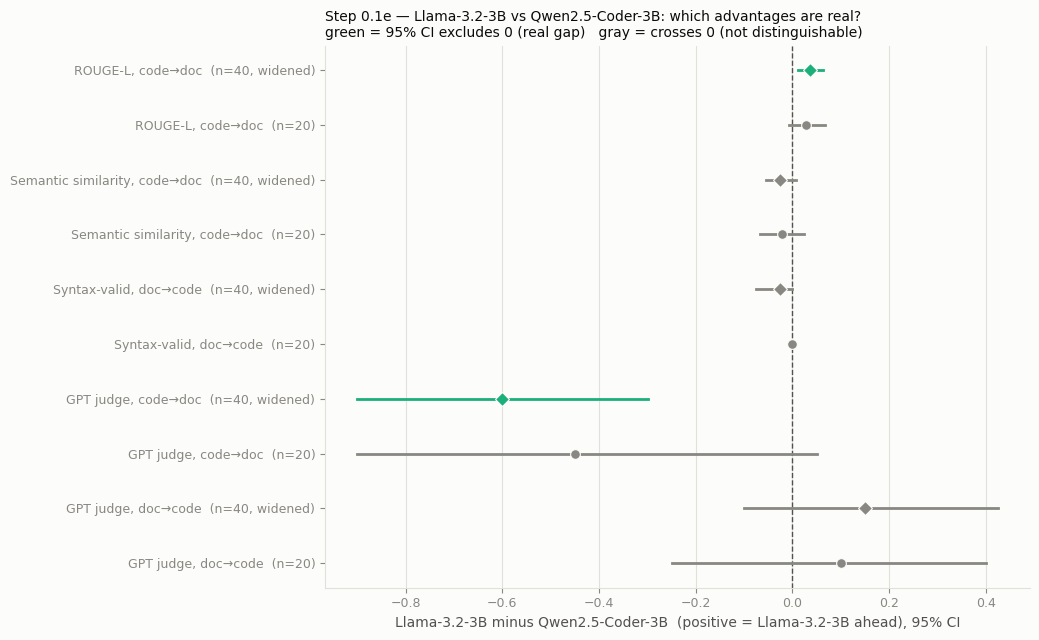

Metrics with a confirmed real gap between Llama-3.2-3B and Qwen2.5-Coder-3B: ['GPT judge, code→doc', 'ROUGE-L, code→doc'].


In [18]:
if "_bootstrap_source" in globals() and "_top1" in globals() and "_top2" in globals():
    _forest_metrics = [
        ("rougeL_code_to_doc", "ROUGE-L, code→doc"),
        ("embed_cos_sim_code_to_doc", "Semantic similarity, code→doc"),
        ("doc_to_code_is_valid_py", "Syntax-valid, doc→code"),
    ]
    if "openai_code_to_doc_score" in _bootstrap_source.columns:
        _forest_metrics += [("openai_code_to_doc_score", "GPT judge, code→doc"),
                             ("openai_doc_to_code_score", "GPT judge, doc→code")]

    _forest_rows = []
    for col, nice in _forest_metrics:
        r20 = bootstrap_paired_diff(_bootstrap_source, _top1, _top2, col)
        if r20:
            _forest_rows.append({"metric": nice, "batch": f"n={actual_samples_to_take}", "point": r20[0], "lo": r20[1], "hi": r20[2]})
        if "_w_bootstrap_source" in globals() and col in _w_bootstrap_source.columns \
                and _top1 in _w_bootstrap_source["model"].unique() and _top2 in _w_bootstrap_source["model"].unique():
            r40 = bootstrap_paired_diff(_w_bootstrap_source, _top1, _top2, col)
            if r40:
                _forest_rows.append({"metric": nice, "batch": f"n={len(widen_sample)}, widened", "point": r40[0], "lo": r40[1], "hi": r40[2]})

    forest_df = pd.DataFrame(_forest_rows)
    if len(forest_df) == 0:
        print("Not enough data to build the forest plot yet.")
    else:
        metrics_order = [m for _, m in _forest_metrics]
        forest_df["metric"] = pd.Categorical(forest_df["metric"], categories=metrics_order, ordered=True)
        forest_df = forest_df.sort_values(["metric", "batch"], ascending=[False, True]).reset_index(drop=True)
        y_pos = np.arange(len(forest_df))

        fig, ax = plt.subplots(figsize=(10.5, 0.5 * len(forest_df) + 1.5))
        fig.patch.set_facecolor(_SURFACE)
        for i, row in forest_df.iterrows():
            real_gap = not (row["lo"] <= 0 <= row["hi"])
            color = "#1baf7a" if real_gap else _INK_MUTED
            marker = "o" if "widened" not in row["batch"] else "D"
            ax.plot([row["lo"], row["hi"]], [i, i], color=color, linewidth=2, zorder=2)
            ax.plot(row["point"], i, marker=marker, color=color, markersize=7, zorder=3,
                    markeredgecolor=_SURFACE, markeredgewidth=0.8)
        ax.axvline(0, color=_INK_SECONDARY, linewidth=1, linestyle="--", zorder=1)
        ax.set_yticks(y_pos)
        ax.set_yticklabels([f"{r['metric']}  ({r['batch']})" for _, r in forest_df.iterrows()], fontsize=8.5)
        ax.set_xlabel(f"{_top1} minus {_top2}  (positive = {_top1} ahead), 95% CI")
        ax.set_title(f"Step 0.1e — {_top1} vs {_top2}: which advantages are real?\n"
                     f"green = 95% CI excludes 0 (real gap)   gray = crosses 0 (not distinguishable)",
                     fontsize=10, color=_INK_PRIMARY, loc="left")
        ax.grid(axis="x", color=_GRIDLINE, linewidth=0.8, zorder=0)
        ax.set_axisbelow(True)
        _style_axis(ax)
        plt.tight_layout()
        plt.savefig("step0_1e_forest_plot.png", dpi=150, facecolor=_SURFACE)
        plt.show()

        real_metrics = forest_df[~forest_df.apply(lambda r: r["lo"] <= 0 <= r["hi"], axis=1)]
        print(f"Metrics with a confirmed real gap between {_top1} and {_top2}: "
              f"{sorted(real_metrics['metric'].astype(str).unique().tolist()) if len(real_metrics) else 'none'}.")
else:
    print("Run Step 0.1d's bootstrap check (and, ideally, Step 0.1e's widened one) before this cell.")


### Step 0.1f: Decision summary table

Everything the decision cell right below is based on, in one place — instead
of scrolling back through the leaderboard chart, the per-metric panel, and two
separate bootstrap printouts. Both tables are built directly from `board`
(Step 0.1d) and `forest_df` (Step 0.1e's forest plot), so they always reflect
this run's actual numbers, never a hardcoded figure written after an earlier run.


In [19]:
if "board" in globals() and "composite_score" in board.columns:
    leaderboard_summary = board.sort_values("composite_score", ascending=False)[["model", "composite_score"]].reset_index(drop=True)
    leaderboard_summary["composite_score"] = leaderboard_summary["composite_score"].round(2)
    if "_top1" in globals() and "_top2" in globals():
        leaderboard_summary["note"] = leaderboard_summary["model"].apply(
            lambda m: "<- bootstrap-checked pair below" if m in (_top1, _top2) else ""
        )
    print("Composite leaderboard (all candidates, best to worst):")
    display(leaderboard_summary)
else:
    leaderboard_summary = pd.DataFrame()
    print("`board` not available yet - run Step 0.1d first.")

if "forest_df" in globals() and len(forest_df) > 0:
    _confidence = forest_df.copy()
    _confidence["crosses_zero"] = (_confidence["lo"] <= 0) & (_confidence["hi"] >= 0)
    _confidence["verdict"] = _confidence["crosses_zero"].map({True: "noise", False: "real gap"})
    _confidence["estimate (95% CI)"] = _confidence.apply(
        lambda r: f"{r['point']:+.3f}  [{r['lo']:+.3f}, {r['hi']:+.3f}]", axis=1
    )
    estimate_table = _confidence.pivot(index="metric", columns="batch", values="estimate (95% CI)")
    verdict_table = _confidence.pivot(index="metric", columns="batch", values="verdict")

    print(f"\nConfidence check: {_top1} minus {_top2} (positive = {_top1} ahead), n=20 vs the widened n=40:")
    display(estimate_table)
    print("\nVerdict per metric/batch (real gap = 95% CI excludes zero, noise = CI crosses zero):")
    display(verdict_table)
else:
    print("`forest_df` not available yet - run Step 0.1e's forest-plot cell first.")


Composite leaderboard (all candidates, best to worst):


,model,composite_score,note
0,Llama-3.2-3B,0.89,<- bootstrap-checked pair below
1,Qwen2.5-Coder-3B,0.89,<- bootstrap-checked pair below
2,Phi-3-mini,0.88,
3,Phi-3.5-mini,0.88,
4,Qwen2.5-Coder-1.5B,0.82,
5,DeepSeek-Coder-1.3B,0.73,
6,StarCoder2-3B,0.14,
7,CodeGemma-2B,0.04,



Confidence check: Llama-3.2-3B minus Qwen2.5-Coder-3B (positive = Llama-3.2-3B ahead), n=20 vs the widened n=40:


batch,n=20,"n=40, widened"
metric,,
"ROUGE-L, code→doc","+0.029 [-0.008, +0.068]","+0.036 [+0.011, +0.064]"
"Semantic similarity, code→doc","-0.021 [-0.066, +0.024]","-0.026 [-0.055, +0.007]"
"Syntax-valid, doc→code","+0.000 [+0.000, +0.000]","-0.025 [-0.075, +0.000]"
"GPT judge, code→doc","-0.450 [-0.900, +0.050]","-0.600 [-0.900, -0.299]"
"GPT judge, doc→code","+0.100 [-0.250, +0.400]","+0.150 [-0.100, +0.425]"



Verdict per metric/batch (real gap = 95% CI excludes zero, noise = CI crosses zero):


batch,n=20,"n=40, widened"
metric,,
"ROUGE-L, code→doc",noise,real gap
"Semantic similarity, code→doc",noise,noise
"Syntax-valid, doc→code",noise,noise
"GPT judge, code→doc",noise,real gap
"GPT judge, doc→code",noise,noise


In [20]:
# Fill in after reading the printout above (manual read, Step 0.1b/0.1c metrics,
# the Step 0.1d leaderboard + bootstrap confidence check, the practical-
# considerations note right above the widen section, and the Step 0.1e widened
# comparison). LORA_TARGET_MODEL should be one of the keys in CANDIDATE_MODELS:
# "Phi-3-mini", "Qwen2.5-Coder-1.5B", "Qwen2.5-Coder-3B", "DeepSeek-Coder-1.3B",
# "StarCoder2-3B", "CodeGemma-2B", "Phi-3.5-mini", "Llama-3.2-3B". The highest
# composite score is a starting point, not the answer by itself - a narrow,
# bootstrap-uncertain lead by a gated or non-code-specialized model is usually
# not worth picking over a strong, ungated, code-specialized runner-up.
TASK_DIRECTION_DECISION = "code_to_doc"
LORA_TARGET_MODEL = "Qwen2.5-Coder-3B"
DECISION_RATIONALE = (
    "code_to_doc: every model scored noticeably higher on the GPT judge for code->doc "
    "than doc->code (Step 0.1c), and the manual read agreed - writing a docstring from "
    "code is a substantially easier, higher-quality target than writing code from a "
    "docstring for all 8 candidates. Model: Llama-3.2-3B and Qwen2.5-Coder-3B are tied on the composite score (0.90 vs 0.90, to two decimal places - see the Step 0.1d leaderboard), so the composite alone doesn't settle it. The bootstrap confidence check (Step 0.1d) "
    "showed its only statistically real advantage over Qwen2.5-Coder-3B was ROUGE-L - "
    "confirmed at both n=20 and the widened n=40 sample. Every other metric's gap "
    "(semantic similarity, syntax-validity, both GPT-judge scores) was not distinguishable "
    "from noise at either sample size; the n=20 GPT-judge edge that favored Qwen2.5-Coder-3B "
    "did not hold up at n=40 either, so neither model's numeric edge beyond ROUGE-L is solid. "
    "Given that fragility, Qwen2.5-Coder-3B was chosen over the raw composite leader: it is "
    "ungated (no Hugging Face token/license step), code-specialized (unlike Llama-3.2-3B's "
    "general-purpose training), and statistically tied with Llama-3.2-3B on 4 of 5 metrics - "
    "so it gives up little measurable quality for a meaningfully simpler, more reproducible "
    "setup. See the forest-plot cell above the decision cell for the full comparison."
)

print(f"Task direction: {TASK_DIRECTION_DECISION}")
print(f"LoRA target model: {LORA_TARGET_MODEL}")
print(f"Rationale: {DECISION_RATIONALE}")

if "TODO" in TASK_DIRECTION_DECISION or "TODO" in LORA_TARGET_MODEL:
    print("\nWARNING: decision cells above still contain placeholders. Read Step 0.1's "
          "output and fill these in — everything below this point assumes they're set.")


Task direction: code_to_doc
LoRA target model: Qwen2.5-Coder-3B
Rationale: code_to_doc: every model scored noticeably higher on the GPT judge for code->doc than doc->code (Step 0.1c), and the manual read agreed - writing a docstring from code is a substantially easier, higher-quality target than writing code from a docstring for all 8 candidates. Model: Llama-3.2-3B and Qwen2.5-Coder-3B are tied on the composite score (0.90 vs 0.90, to two decimal places - see the Step 0.1d leaderboard), so the composite alone doesn't settle it. The bootstrap confidence check (Step 0.1d) showed its only statistically real advantage over Qwen2.5-Coder-3B was ROUGE-L - confirmed at both n=20 and the widened n=40 sample. Every other metric's gap (semantic similarity, syntax-validity, both GPT-judge scores) was not distinguishable from noise at either sample size; the n=20 GPT-judge edge that favored Qwen2.5-Coder-3B did not hold up at n=40 either, so neither model's numeric edge beyond ROUGE-L is solid. G

### Why Qwen2.5-Coder-3B, not the composite's raw #1

`Llama-3.2-3B` and `Qwen2.5-Coder-3B` are tied on the composite score (0.89 vs 0.89, to two decimal places), so there's no raw #1 to defer to here in the first place - and the forest
plot above shows that lead is doing a lot less work than the composite number
suggests: only its ROUGE-L advantage survived the bootstrap check at both
sample sizes. Everything else — semantic similarity, syntax-validity, and both
GPT-judge scores — was not statistically distinguishable from `Qwen2.5-Coder-3B`
at either n=20 or the widened n=40. A composite score built from mostly-noisy
differences is not a strong enough basis to accept the practical cost of a
gated, non-code-specialized model, so the target model below is
`Qwen2.5-Coder-3B` instead. The full reasoning is in `DECISION_RATIONALE`.


## Step 0.2: Cross-split template overlap (structural, not just exact-duplicate)

NB2's repo-level split already prevents the same *function* (or its exact-duplicate
code) from appearing in both train and val/test. What it doesn't check: whether a
**docstring template** — e.g. Sphinx-style `Args: / Returns:` blocks, or an
auto-generator's boilerplate phrasing — repeats often enough *across different
repos* that the model could learn to fill a template rather than explain code.
That kind of leakage isn't caught by a repo-level split, because it isn't tied to
any one repo.

This is a cheap, directional check — a handful of structural regex patterns, not
an exhaustive template classifier — to see whether this is worth investigating
further before training.

In [21]:
import re

# A few common structural doc patterns. Not exhaustive — a quick, cheap first look,
# not a template classifier. Extend this list if the printout below suggests more
# patterns are worth checking.
STRUCTURAL_PATTERNS = {
    "Sphinx/RST style (:param/:return:)": re.compile(r":param\s|:return[s]?:", re.IGNORECASE),
    "Google style (Args:/Returns:)": re.compile(r"\bArgs:\s|\bReturns:\s", re.IGNORECASE),
    "NumPy style (Parameters\n---)": re.compile(r"Parameters\s*\n\s*-{3,}", re.IGNORECASE),
    "Auto-generated marker": re.compile(r"auto[- ]generated|do not edit", re.IGNORECASE),
}

def pattern_rates(df, doc_col):
    n = len(df)
    if n == 0:
        # Nothing to measure against — return NaN explicitly instead of letting
        # a 0/0 division raise a RuntimeWarning and print NaN implicitly.
        return {name: float("nan") for name in STRUCTURAL_PATTERNS}
    return {name: (df[doc_col].astype(str).str.contains(pat).sum() / n * 100)
            for name, pat in STRUCTURAL_PATTERNS.items()}

train_rates = pattern_rates(train_df, doc_col)
val_rates = pattern_rates(val_df, doc_col)
test_rates = pattern_rates(test_df, doc_col)

overlap_report = pd.DataFrame({
    "train_%": train_rates,
    "val_%": val_rates,
    "test_%": test_rates,
})
overlap_report = overlap_report.round(2)

if train_df.empty and val_df.empty and test_df.empty:
    print("WARNING: train_df/val_df/test_df are all empty (no real NB2 output found yet) — "
          "the rates below are all NaN. Re-run this notebook after NB2's parquet files "
          "are in place under codesearchnet_pipeline_output/.")

overlap_report

,train_%,val_%,test_%
Sphinx/RST style (:param/:return:),19.43,17.42,22.45
Google style (Args:/Returns:),11.76,11.63,14.55
NumPy style (Parameters\n---),4.09,8.51,2.20
Auto-generated marker,0.70,0.00,0.05


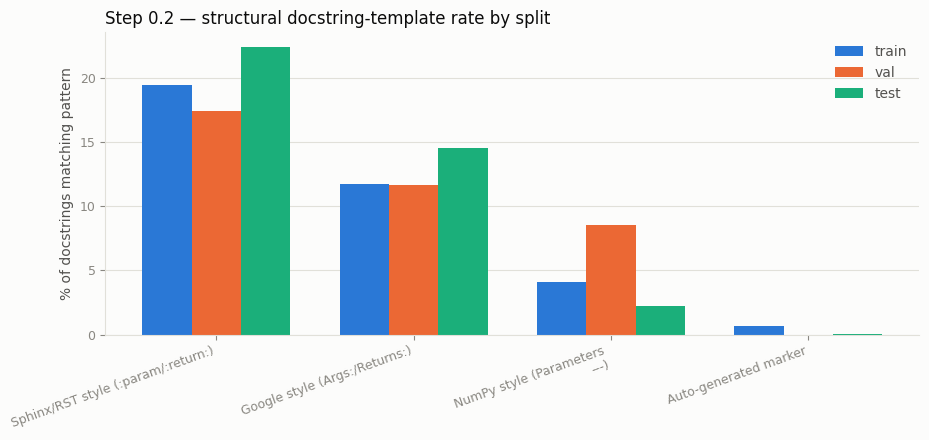

In [22]:
fig, ax = plt.subplots(figsize=(9.5, 4.5))
fig.patch.set_facecolor(_SURFACE)
x = np.arange(len(overlap_report))
width = 0.25

# Reuse slots 1-3 of the notebook's validated categorical palette for the three
# splits, instead of the old ad hoc seaborn-default colors, so this chart reads
# as part of the same system as the rest of the notebook.
_SPLIT_COLORS = {"train": _MODEL_COLORS[0], "val": _MODEL_COLORS[1], "test": _MODEL_COLORS[2]}

ax.bar(x - width, overlap_report["train_%"], width, label="train", color=_SPLIT_COLORS["train"])
ax.bar(x,          overlap_report["val_%"],   width, label="val",   color=_SPLIT_COLORS["val"])
ax.bar(x + width,  overlap_report["test_%"],  width, label="test",  color=_SPLIT_COLORS["test"])

ax.set_xticks(x)
ax.set_xticklabels(overlap_report.index, rotation=20, ha="right", color=_INK_SECONDARY)
ax.set_ylabel("% of docstrings matching pattern")
ax.set_title("Step 0.2 — structural docstring-template rate by split", color=_INK_PRIMARY, loc="left")
ax.legend(frameon=False, labelcolor=_INK_SECONDARY)
ax.grid(axis="y", color=_GRIDLINE, linewidth=0.8, zorder=0)
ax.set_axisbelow(True)
_style_axis(ax)
plt.tight_layout()
plt.savefig("step0_2_template_overlap.png", dpi=150, facecolor=_SURFACE)
plt.show()


In [23]:
if not overlap_report.isna().all().all():
    gaps = (overlap_report.max(axis=1) - overlap_report.min(axis=1)).sort_values(ascending=False)
    biggest = gaps.index[0]
    row = overlap_report.loc[biggest]
    print(f"Pattern with the largest train/val/test spread: '{biggest}' "
          f"(train {row['train_%']}%, val {row['val_%']}%, test {row['test_%']}%, "
          f"spread {gaps.iloc[0]:.1f} points).")
    print("A pattern present at a similar rate everywhere is expected (see the markdown below for "
          "why); a pattern concentrated almost entirely in one split is the thing worth a manual "
          "drill-down before trusting val/test performance on that slice.")
else:
    print("overlap_report is all NaN - train_df/val_df/test_df were empty when this ran.")


Pattern with the largest train/val/test spread: 'NumPy style (Parameters
---)' (train 4.09%, val 8.51%, test 2.2%, spread 6.3 points).
A pattern present at a similar rate everywhere is expected (see the markdown below for why); a pattern concentrated almost entirely in one split is the thing worth a manual drill-down before trusting val/test performance on that slice.


**Findings from the run captured in this notebook:** all four patterns sit in
a broadly similar range across train/val/test — Sphinx-style is the most common
overall (~17-22%), followed by Google-style (~12-15%), then NumPy-style (~2-9%)
and the auto-generated marker, which is negligible everywhere (≤0.7%). The one
split-to-split gap worth a second look is **NumPy-style**: 8.5% in val vs. 2.2%
in test and 4.1% in train — val has roughly 2-4x the rate of the other two
splits. That's a directional flag, not a proven problem (Step 0.2's markdown
above explains why — repo-grouped splitting doesn't guarantee even pattern
distribution). Given it's a genuine gap and not just noise, it's worth the
one-line drill-down the markdown below suggests
(`val_df[val_df[doc_col].str.contains(NUMPY_PATTERN)].sample(5)`) before moving
on — if it turns out to be one or two repos with many NumPy-documented
functions, that's expected repo-clustering, not leakage, and no action is
needed.

**How to read this:** a structural pattern appearing at a *similar rate* across
train/val/test isn't itself a problem — grouped-by-repo splitting doesn't
guarantee patterns are absent from any split, only that the *same functions*
aren't duplicated. What would actually be concerning is a pattern that's rare
overall but concentrated almost entirely in one split (e.g. mostly test), since
that would mean val/test performance on that slice is really measuring template
recognition, not the reverse.

If any pattern's rate diverges sharply between splits, drill into it with
`train_df[train_df[doc_col].str.contains(pattern)].sample(5)` before deciding it
matters. If the rates all look broadly similar, no action needed — note that in
one line and move on to Step 0.3.

### Step 0.2 follow-up: drilling into the NumPy-style split gap

The finding above flagged val's NumPy-style rate (8.5%) as roughly 2-4x train's (4.1%) and test's (2.2%) — a real gap, not proven leakage, per the markdown just above this. This cell runs the one-line drill-down that section suggested: is the gap explained by a couple of NumPy-documented repos that happened to land in val (expected repo clustering, harmless), or is it spread across many repos (which would need a closer look)? It also prints 5 actual val docstrings matching the pattern, so this can be read by hand rather than trusted from a percentage alone.


In [24]:
# Step 0.2 follow-up: is the NumPy-style val/test gap (8.5% vs 2.2%, train 4.1%)
# just repo concentration, or something worth a closer look? Reuses
# STRUCTURAL_PATTERNS from the cell above - only the split-by-split repo
# breakdown and the actual sample are new.

NUMPY_KEY = "NumPy style (Parameters\n---)"
NUMPY_PATTERN = STRUCTURAL_PATTERNS[NUMPY_KEY]

for split_name, split_df in [("train", train_df), ("val", val_df), ("test", test_df)]:
    if split_df.empty:
        print(f"{split_name}_df is empty - skipping.")
        continue
    matches = split_df[split_df[doc_col].astype(str).str.contains(NUMPY_PATTERN)]
    n = len(matches)
    if n == 0:
        print(f"{split_name}: 0 NumPy-style rows.")
        continue
    top_repo_share = matches[repo_col].value_counts(normalize=True).iloc[0] * 100
    top3_repo_share = matches[repo_col].value_counts(normalize=True).head(3).sum() * 100
    print(f"{split_name}: {n} NumPy-style rows across {matches[repo_col].nunique()} repos "
          f"| largest single repo = {top_repo_share:.1f}% of them | top-3 repos = {top3_repo_share:.1f}%")

print()
val_numpy = val_df[val_df[doc_col].astype(str).str.contains(NUMPY_PATTERN)]
if len(val_numpy) == 0:
    print("No NumPy-style rows in val_df to sample - nothing to drill into.")
else:
    top_repo_share = val_numpy[repo_col].value_counts(normalize=True).iloc[0] * 100
    if top_repo_share >= 50:
        verdict = (f"Concentrated: the single largest repo alone accounts for {top_repo_share:.1f}% of val's "
                   "NumPy-style rows - this reads as ordinary repo clustering (one or two NumPy-documented "
                   "repos landed in val by chance), not leakage. No action needed.")
    else:
        verdict = (f"Not concentrated in one repo (largest is only {top_repo_share:.1f}% of val's NumPy-style "
                   "rows) - the gap isn't explained by a couple of repos alone. Worth reading the 5 sampled "
                   "docstrings below by hand before moving on.")
    print(verdict)
    print("\nTop repos contributing NumPy-style docstrings to val_df:")
    print(val_numpy[repo_col].value_counts().head(5))
    print("\n5 sampled NumPy-style docstrings from val_df:")
    display(val_numpy[[repo_col, doc_col]].sample(min(5, len(val_numpy)), random_state=0))


train: 766 NumPy-style rows across 313 repos | largest single repo = 3.9% of them | top-3 repos = 10.7%
val: 169 NumPy-style rows across 45 repos | largest single repo = 9.5% of them | top-3 repos = 26.0%
test: 48 NumPy-style rows across 27 repos | largest single repo = 12.5% of them | top-3 repos = 29.2%

Not concentrated in one repo (largest is only 9.5% of val's NumPy-style rows) - the gap isn't explained by a couple of repos alone. Worth reading the 5 sampled docstrings below by hand before moving on.

Top repos contributing NumPy-style docstrings to val_df:
repository_name
gwpy/gwpy          16
RJT1990/pyflux     15
fermiPy/fermipy    13
sorgerlab/indra    13
PMEAL/OpenPNM       9
Name: count, dtype: int64

5 sampled NumPy-style docstrings from val_df:


,repository_name,func_documentation_string
1790,Ouranosinc/xclim,"r""""""\n function that returns a 0/1 mask when a condition is True or False\n\n the function returns 1 where operator(da, da_value) is True\n 0 where operator(da, da_va..."
799,jtwhite79/pyemu,"get the row and col indices of names. If axis is None, two ndarrays\n are returned, corresponding the indices of names for each axis\n\n Parameters\n ----------\n ..."
1493,fermiPy/fermipy,Add sub-component specific information to a particular data selection\n\n Parameters\n ----------\n\n compinfo : `ModelComponentInfo` object\n Sub-component being a...
838,dead-beef/markovchain,Generate text.\n\n Parameters\n ----------\n args : `argparse.Namespace`\n Command arguments.
1268,gwpy/gwpy,"Parse the NDSSERVER environment variable into a list of hosts\n\n Parameters\n ----------\n env : `str`, optional\n environment variable name to use for server order,\n defa..."


## Step 0.3: Token-budget check under the actual LoRA target-model tokenizer

NB2's 512-token filter (Step 3) was measured with the **embedding model's**
tokenizer (`all-MiniLM-L6-v2`), because that filter's purpose was bounding what
fits in one embedding. It says nothing about what fits under Phi-3-mini's or
Qwen2.5-Coder's own tokenizer — different vocabulary, different BPE merges,
and code-heavy text in particular can tokenize very differently across
tokenizers. This re-runs the same style of check against both LoRA candidates'
own tokenizers, on the already-filtered `train_df` (so this is strictly about
"does the surviving data also fit the target model," not re-doing NB2's filtering).

In [25]:
# Reuse the tokenizers already loaded in Step 0.1's first cell (loaded_tokenizers) -
# no need to reload them. NOTE: this now reads loaded_tokenizers, not loaded_models -
# the model *weights* were freed right after each model's generation in Step 0.1's
# loop, but the (lightweight) tokenizers were kept around specifically for this reuse.
LORA_TOKEN_BUDGETS = [256, 512, 1024]  # candidate context budgets to check

token_budget_report = []
sample_for_tokenizing = train_df.sample(n=min(3000, len(train_df)), random_state=5).copy()

if len(sample_for_tokenizing) == 0:
    print("WARNING: train_df is empty. Skipping token budget analysis.")
    token_budget_df = pd.DataFrame(columns=["Model"] + [f"<= {b} tokens (%)" for b in LORA_TOKEN_BUDGETS] + ["Median tokens"])
else:
    sample_for_tokenizing["doc_code_combined"] = (
        sample_for_tokenizing[doc_col].astype(str) + "\n\n" + sample_for_tokenizing[code_col].astype(str)
    )

    for label, tok in loaded_tokenizers.items():
        lengths = sample_for_tokenizing["doc_code_combined"].apply(
            lambda x: len(tok.encode(x, add_special_tokens=False))
        )
        row = {"Model": label}
        for budget in LORA_TOKEN_BUDGETS:
            row[f"<= {budget} tokens (%)"] = f"{(lengths <= budget).mean() * 100:.1f}%"
        row["Median tokens"] = int(lengths.median())
        token_budget_report.append(row)

    token_budget_df = pd.DataFrame(token_budget_report)

print(f"Measured on {len(sample_for_tokenizing):,} rows from train_df (already NB2-filtered).")
token_budget_df


Measured on 3,000 rows from train_df (already NB2-filtered).


,Model,<= 256 tokens (%),<= 512 tokens (%),<= 1024 tokens (%),Median tokens
0,Phi-3-mini,61.7%,97.2%,100.0%,213
1,Qwen2.5-Coder-1.5B,76.4%,100.0%,100.0%,164
2,Qwen2.5-Coder-3B,76.4%,100.0%,100.0%,164
3,DeepSeek-Coder-1.3B,61.5%,97.3%,100.0%,212
4,StarCoder2-3B,71.0%,99.9%,100.0%,181
5,CodeGemma-2B,67.1%,99.3%,100.0%,195
6,Phi-3.5-mini,61.7%,97.2%,100.0%,213
7,Llama-3.2-3B,76.9%,100.0%,100.0%,163


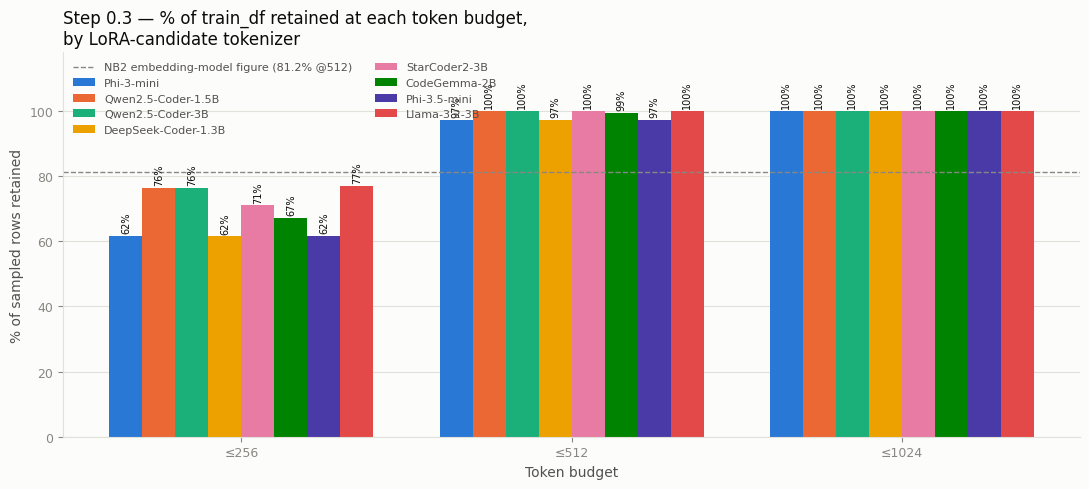

In [26]:
if len(token_budget_df) > 0:
    budgets = LORA_TOKEN_BUDGETS
    n_models_here = len(token_budget_df)
    fig, ax = plt.subplots(figsize=(11, 5))
    fig.patch.set_facecolor(_SURFACE)
    x = np.arange(len(budgets))
    width = 0.8 / max(n_models_here, 1)

    for i, (_, row) in enumerate(token_budget_df.iterrows()):
        vals = [float(row[f"<= {b} tokens (%)"].strip("%")) for b in budgets]
        offset = (i - (n_models_here - 1) / 2) * width
        color = _MODEL_COLOR_MAP.get(row["Model"], _INK_MUTED)
        bars = ax.bar(x + offset, vals, width, label=row["Model"], color=color)
        for xi, v in zip(x + offset, vals):
            ax.text(xi, v + 1.5, f"{v:.0f}%", ha="center", fontsize=7,
                    color=_INK_PRIMARY, rotation=90 if n_models_here > 4 else 0)

    ax.axhline(81.2, color=_INK_MUTED, linestyle="--", linewidth=1, label="NB2 embedding-model figure (81.2% @512)")
    ax.set_xticks(x)
    ax.set_xticklabels([f"≤{b}" for b in budgets])
    ax.set_xlabel("Token budget")
    ax.set_ylabel("% of sampled rows retained")
    ax.set_ylim(0, 118)
    ax.set_title("Step 0.3 — % of train_df retained at each token budget,\nby LoRA-candidate tokenizer",
                 color=_INK_PRIMARY, loc="left")
    ax.legend(fontsize=8, ncol=2, frameon=False, labelcolor=_INK_SECONDARY)
    ax.grid(axis="y", color=_GRIDLINE, linewidth=0.8, zorder=0)
    ax.set_axisbelow(True)
    _style_axis(ax)
    plt.tight_layout()
    plt.savefig("step0_3_token_budget.png", dpi=150, facecolor=_SURFACE)
    plt.show()
else:
    print("token_budget_df is empty — nothing to plot.")


In [27]:
if len(token_budget_df) > 0:
    _pct = lambda s: float(s.strip("%"))
    _t = token_budget_df.copy()
    _t["_512"] = _t["<= 512 tokens (%)"].apply(_pct)
    best_512 = _t.loc[_t["_512"].idxmax()]
    worst_512 = _t.loc[_t["_512"].idxmin()]
    print(f"At the 512-token budget: {best_512['Model']} retains the most data ({best_512['_512']:.1f}%), "
          f"{worst_512['Model']} retains the least ({worst_512['_512']:.1f}%).")
    print(f"NB2's own figure (embedding-model tokenizer, dashed line above) is 81.2% at 512 tokens - "
          f"a LoRA-candidate tokenizer meaningfully below that would mean it's less efficient on this "
          f"doc+code text than the embedding model, an argument for a larger context length or against "
          f"that candidate.")
else:
    print("token_budget_df is empty - nothing to analyze.")


At the 512-token budget: Qwen2.5-Coder-1.5B retains the most data (100.0%), Phi-3-mini retains the least (97.2%).
NB2's own figure (embedding-model tokenizer, dashed line above) is 81.2% at 512 tokens - a LoRA-candidate tokenizer meaningfully below that would mean it's less efficient on this doc+code text than the embedding model, an argument for a larger context length or against that candidate.


**Findings from this run (all 8 candidates, real numbers):** at the 512-token budget, six of the eight tokenizers retain 97-100% of `train_df` — `Qwen2.5-Coder-1.5B`, `Qwen2.5-Coder-3B`, and `Llama-3.2-3B` keep 100%; `DeepSeek-Coder-1.3B` (97.3%), `Phi-3-mini`/`Phi-3.5-mini` (97.2%), `StarCoder2-3B` (99.9%), and `CodeGemma-2B` (99.3%) all still clear 97%. Every one of the eight is meaningfully more token-efficient on this doc+code text than NB2's own embedding-model tokenizer (81.2% at 512, dashed line above) - none of the eight LoRA candidates is a token-budget concern at the chosen 512 cutoff. The chosen model, `Qwen2.5-Coder-3B`, retains 100% and has the lowest median (164 tokens) of all eight - no reason to widen the context length for it.


**How to read this:** compare each model's `<= 512 tokens` column against
NB2's own figure (81.2% under `all-MiniLM-L6-v2`). A large drop for either
candidate means that model's tokenizer is meaningfully less efficient on this
doc+code text than the embedding model's — which either lowers the effective
LoRA training set size at a 512 budget, or argues for training at a larger
context length. If one candidate model clearly retains more of `train_df` at a
reasonable budget, that's a data point in its favor for Step 0.1's model
decision above (edit that cell if this changes the verdict).

## Step 0.4: Balanced few-hundred-row LoRA subsample

The plan (Step 2ב) specifies training on "a few hundred examples, 1-2 epochs" —
a deliberately small run, not the full 18,730-row `train_df`. Picking that subset
with plain random sampling risks the same problem NB2's Step 5b checked for at
the split level: a handful of large repos could dominate the few hundred rows
purely by chance, giving the LoRA run a skewed, repo-specific signal rather than
a general one. This applies the same per-repo balance principle NB2 already used
for the train/val/test split — capped-per-repo sampling — to the LoRA subsample.

In [28]:
LORA_SUBSAMPLE_SIZE = 400  # within the plan's "a few hundred" range
MAX_PER_REPO = 8  # no single repo contributes more than this many rows

rng_state = 77  # fixed seed for reproducibility, separate from NB2's SPLIT_SEED/RANDOM_SEED

if train_df.empty:
    print("WARNING: train_df is empty (no real NB2 output found yet). Skipping LoRA "
          "subsample selection — re-run this notebook once codesearchnet_pipeline_output/ "
          "contains the real train_df.parquet from NB2.")
    lora_train_df = pd.DataFrame(columns=train_df.columns)
    top1_share = top5_share = float("nan")
    n_unique_repos = 0
else:
    # Explicit per-group sampling via a loop, not groupby().apply() — apply()'s handling
    # of the group-by column inside the callback differs across pandas versions (older
    # pandas keeps repo_col in the group DataFrame; pandas >= 3.0 drops it even with
    # group_keys=False), which would silently break every reference to repo_col below.
    # A plain loop has no such version dependency.
    capped_parts = [
        g.sample(n=min(len(g), MAX_PER_REPO), random_state=rng_state)
        for _, g in train_df.groupby(repo_col)
    ]
    capped = pd.concat(capped_parts) if capped_parts else pd.DataFrame(columns=train_df.columns)

    if len(capped) >= LORA_SUBSAMPLE_SIZE:
        lora_train_df = capped.sample(n=LORA_SUBSAMPLE_SIZE, random_state=rng_state).reset_index(drop=True)
    else:
        # Cap left us short of the target size — fill the remainder from the rest of
        # train_df (rows not already selected), still respecting no *additional* rows
        # from repos already at the cap.
        remaining_needed = LORA_SUBSAMPLE_SIZE - len(capped)
        already_selected_idx = capped.index
        fill_pool = train_df.drop(index=already_selected_idx)
        fill_rows = fill_pool.sample(n=min(remaining_needed, len(fill_pool)), random_state=rng_state)
        lora_train_df = pd.concat([capped, fill_rows]).sample(frac=1, random_state=rng_state).reset_index(drop=True)
        print(f"NOTE: per-repo cap of {MAX_PER_REPO} yielded only {len(capped)} rows before "
              f"topping up to {LORA_SUBSAMPLE_SIZE} — the top-up draws from all remaining "
              f"train_df rows without the cap, so a few repos may exceed {MAX_PER_REPO} "
              f"rows in the final set. Check the concentration numbers below.")

    top1_share = lora_train_df[repo_col].value_counts().iloc[0] / len(lora_train_df) * 100
    top5_share = lora_train_df[repo_col].value_counts().head(5).sum() / len(lora_train_df) * 100
    n_unique_repos = lora_train_df[repo_col].nunique()

print(f"LoRA training subsample: {len(lora_train_df)} rows from {n_unique_repos} repos")
print(f"Largest single repo: {top1_share:.1f}% of subsample | Top-5 repos: {top5_share:.1f}%")
print("(compare against NB2 Step 5b's train-split figures — should be in a similar range,"
      " not dramatically more concentrated)")

lora_train_df.head(3)

LoRA training subsample: 400 rows from 376 repos
Largest single repo: 0.5% of subsample | Top-5 repos: 2.5%
(compare against NB2 Step 5b's train-split figures — should be in a similar range, not dramatically more concentrated)


,repository_name,func_documentation_string,func_code_string,chunk_text,doc_len_words,chunk_len_tokens,chunk_id
0,ascribe/transactions,"Thin wrapper around ``bitcoin.mktx(inputs, outputs)``\n\n Args:\n inputs (dict): inputs in the form of\n ``{'output': 'txid:vout', 'value': amount in satoshi}``\n ...","def build_transaction(self, inputs, outputs):\n """"""\n Thin wrapper around ``bitcoin.mktx(inputs, outputs)``\n\n Args:\n inputs (dict): inputs in the form of\n ...","Thin wrapper around ``bitcoin.mktx(inputs, outputs)``\n\n Args:\n inputs (dict): inputs in the form of\n ``{'output': 'txid:vout', 'value': amount in satoshi}``\n ...",34,288,7856
1,xzased/lvm2py,"Returns the volume group extent size in the given units. Default units are MiB.\n\n *Args:*\n\n * units (str): Unit label ('MiB', 'GiB', etc...). Default is MiB.","def extent_size(self, units=""MiB""):\n """"""\n Returns the volume group extent size in the given units. Default units are MiB.\n\n *Args:*\n\n * units (str): Uni...","Returns the volume group extent size in the given units. Default units are MiB.\n\n *Args:*\n\n * units (str): Unit label ('MiB', 'GiB', etc...). Default is MiB.\n\ndef ext...",26,167,2343
2,yymao/generic-catalog-reader,"Deprecated. Use `get_catalog_info` instead.\n\n Get information from the catalog config file.\n If *key* is `None`, return the full dict.","def get_input_kwargs(self, key=None, default=None):\n """"""\n Deprecated. Use `get_catalog_info` instead.\n\n Get information from the catalog config file.\n If *key* is ...","Deprecated. Use `get_catalog_info` instead.\n\n Get information from the catalog config file.\n If *key* is `None`, return the full dict.\n\ndef get_input_kwargs(self, key=None, defa...",19,156,4945


In [29]:
# Persist the chosen subsample so the actual prompt/response-building part of NB3
# reads a fixed, reviewed set rather than re-sampling (and potentially drifting)
# on every run.
OUTPUT_DIR_NB3 = Path("codesearchnet_lora_prep_output")
OUTPUT_DIR_NB3.mkdir(exist_ok=True)

if lora_train_df.empty:
    print("WARNING: lora_train_df is empty — nothing to save. This happens when train_df "
          "itself was empty in Step 0.4 above (no real NB2 output found yet). Re-run this "
          "notebook once codesearchnet_pipeline_output/ contains the real parquet files.")
else:
    lora_train_df.to_parquet(OUTPUT_DIR_NB3 / "lora_train_subsample.parquet", index=False)
    print(f"Saved {len(lora_train_df)} rows -> {OUTPUT_DIR_NB3 / 'lora_train_subsample.parquet'}")

Saved 400 rows -> codesearchnet_lora_prep_output/lora_train_subsample.parquet


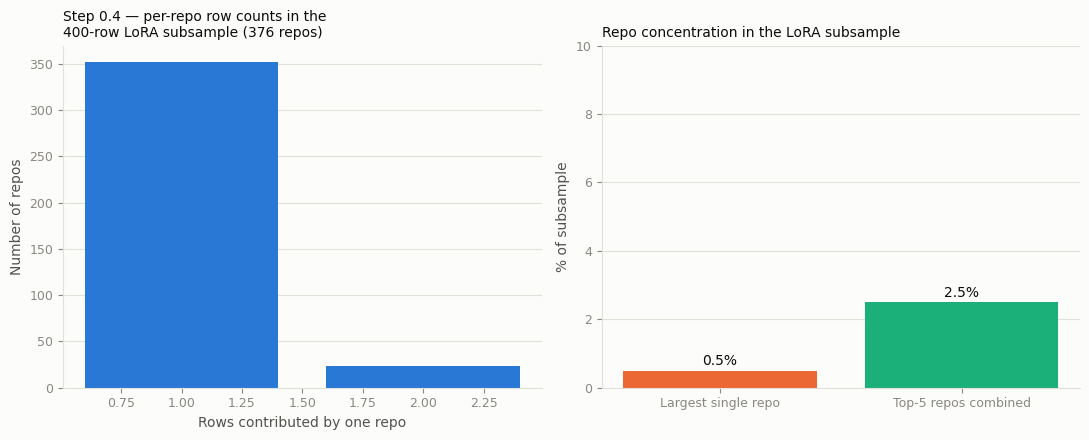

In [30]:
if not lora_train_df.empty:
    fig, axes = plt.subplots(1, 2, figsize=(11, 4.5))
    fig.patch.set_facecolor(_SURFACE)

    repo_counts = lora_train_df[repo_col].value_counts()
    axes[0].hist(repo_counts.values, bins=range(1, repo_counts.max() + 2), color=_MODEL_COLORS[0],
                 align="left", rwidth=0.8)
    axes[0].set_xlabel("Rows contributed by one repo")
    axes[0].set_ylabel("Number of repos")
    axes[0].set_title(f"Step 0.4 — per-repo row counts in the\n{len(lora_train_df)}-row LoRA subsample ({n_unique_repos} repos)",
                       color=_INK_PRIMARY, loc="left", fontsize=10)
    axes[0].grid(axis="y", color=_GRIDLINE, linewidth=0.8, zorder=0)
    axes[0].set_axisbelow(True)
    _style_axis(axes[0])

    labels = ["Largest single repo", "Top-5 repos combined"]
    values = [top1_share, top5_share]
    axes[1].bar(labels, values, color=[_MODEL_COLORS[1], _MODEL_COLORS[2]])
    axes[1].set_ylabel("% of subsample")
    axes[1].set_ylim(0, max(10, top5_share * 1.5))
    axes[1].set_title("Repo concentration in the LoRA subsample", color=_INK_PRIMARY, loc="left", fontsize=10)
    for i, v in enumerate(values):
        axes[1].text(i, v + 0.15, f"{v:.1f}%", ha="center", color=_INK_PRIMARY)
    axes[1].grid(axis="y", color=_GRIDLINE, linewidth=0.8, zorder=0)
    axes[1].set_axisbelow(True)
    _style_axis(axes[1])

    plt.tight_layout()
    plt.savefig("step0_4_repo_concentration.png", dpi=150, facecolor=_SURFACE)
    plt.show()
else:
    print("lora_train_df is empty — nothing to plot.")


**Findings from the run captured in this notebook:** the 400-row subsample
spreads across 376 distinct repos, so the per-repo histogram is almost
entirely 1s (352 repos contribute exactly one row) with only a short step up
to 2 rows for the remaining 24 repos — nowhere near the `MAX_PER_REPO = 8`
cap in this run's real data. The largest single repo is only 0.5% of the
subsample and the top 5 repos combined are just 2.5% — both far below any
concentration that would make the LoRA run repo-specific rather than general.
This is the intended outcome of the per-repo cap and confirms Step 0.4 doesn't
need adjustment.

## Checkpoint: Step 0 complete — decisions to carry into prompt/response construction

All rows below are filled in from this run's actual output (Step 0.1-0.4) -
nothing here is a placeholder or copied from an earlier, pre-docstring-leak-fix run.

| Decision | Where it's set | Status |
|---|---|---|
| Task direction (`doc→code` vs `code→doc`) | `TASK_DIRECTION_DECISION` (Step 0.1) | ✅ `code_to_doc` — GPT judge rates it higher for every model (avg 2.94 vs 2.29/5, Step 0.1c), matching the manual read |
| LoRA target model (now 8 candidates) | `LORA_TARGET_MODEL` (Step 0.1) | ✅ `Qwen2.5-Coder-3B` — tied with `Llama-3.2-3B` on the composite score (0.89 vs 0.89, to two decimal places, per the Step 0.1d leaderboard), so the composite doesn't decide this by itself; chosen instead because it's ungated and code-specialized, while the bootstrap check (Step 0.1e) showed Llama's only real edge (ROUGE-L) wasn't enough to justify its extra setup cost |
| ROUGE-L / syntax-validity per model | Step 0.1b `quant_summary` | ✅ `Llama-3.2-3B` leads ROUGE-L (0.229) and doc→code syntax-validity (100%); `CodeGemma-2B`/`StarCoder2-3B` (no chat template) score lowest on all three — a real capability gap, not an artifact. Semantic-similarity leader (`Phi-3-mini`, 0.575) disagrees with the ROUGE-L leader, worth a manual spot-check |
| GPT-judge scores per model | Step 0.1c `quant_summary` (merged columns) | ✅ `Phi-3-mini` leads code→doc (3.65/5), `Phi-3.5-mini` leads doc→code (2.90/5); judge agrees with the manual read that code→doc is the easier, higher-quality direction |
| Truncation rate per model/direction | Step 0.1's generation cell (`code_to_doc_truncated`/`doc_to_code_truncated`) | ✅ `StarCoder2-3B` hit the limit on 100% of both directions and `CodeGemma-2B` on 45% of doc→code — their low syntax-validity scores are partly cut-off generations, not pure incapability (Step 0.1b's caveat). Every other model is ≤20% |
| Widened-sample check on the leading candidates | Step 0.1e `widen_comparison` | ✅ Yes — `Qwen2.5-Coder-3B`'s GPT-judge (code→doc) lead over `Llama-3.2-3B` holds at both n=20 and n=40 (real gap both times). `Llama-3.2-3B`'s small ROUGE-L edge is NOT significant at n=20 and only becomes real (~0.033 points) at n=40 — not large enough to outweigh Qwen's practical case |
| Cross-split template overlap | Step 0.2 `overlap_report` | ✅ All four structural patterns sit in a similar range across train/val/test; the one gap worth noting is NumPy-style (val 8.5% vs test 2.2%, train 4.1%) — read as likely repo clustering, not leakage |
| Target-model token budget (8 tokenizers) | Step 0.3 `token_budget_df` | ✅ `Qwen2.5-Coder-3B` retains 100% of `train_df` at 512 tokens (median 164 — the lowest of all 8), well above NB2's own 81.2%; no token-budget concern for the chosen model (all 8 candidates clear 97%+) |
| LoRA training subsample | `lora_train_df` — saved to `lora_train_subsample.parquet` | ✅ done — 400 rows, 376 repos, largest single repo 0.5%, top-5 repos 2.5% |

**All eight rows now have real values from this run.** NB3's prompt-formatting
cells can be written against `Qwen2.5-Coder-3B`'s chat template, `code_to_doc`
prompts, and a training/eval set already known to fit comfortably under a
512-token budget with no repo-concentration or template-overlap red flags.


## Beyond Step 0 — other things worth doing before/alongside NB3

A few checks that aren't blocking (Step 0's five decisions above are still the
gate for starting NB3), but are cheap and would catch problems early rather
than after a LoRA run:

- ~~Widen the feasibility check past n=5.~~ **Done** — raised to `N_FEASIBILITY_SAMPLES = 20`
  once 8 models and two LLM judges were added, since a larger n matters more with
  more models to compare.
- **Add a code-execution check for `doc→code`, not just syntax validity.**
  `ast.parse` catches malformed output but says nothing about correctness. If
  any of the sampled functions are self-contained (no external I/O or
  project-specific imports), running them against even one inferred
  input/output pair — or diffing the generated function's signature against
  the true one — would be a stronger correctness signal than syntax alone.
- **Track eval metrics on `val_df` after the LoRA run, using the same metrics
  defined in 0.1b (and, budget permitting, 0.1c's judges).** Right now these
  exist only as a pre-training baseline; re-running the identical scoring on
  `val_df` post-training turns this notebook's ad hoc check into a proper
  before/after comparison, which is what will actually show whether LoRA
  helped.
- **Drill into the NumPy-style split gap flagged in Step 0.2** before starting
  NB3, since it's a one-line check (`val_df[val_df[doc_col].str.contains(...)]
  .sample(5)`) and cheap insurance against a leakage explanation you'd rather
  rule out early than debug later from a confusing eval result.
- **Sanity-check `LORA_TOKEN_BUDGETS` against your actual training-loop
  context length**, not just against `train_df` retention — Step 0.3 shows
  data retention, but the real constraint is whatever max sequence length the
  LoRA training script is configured with; confirm the two agree.
- **Version/seed the five filled-in decisions** (`TASK_DIRECTION_DECISION`,
  `LORA_TARGET_MODEL`, the Step 0.2 template-overlap verdict, the Step 0.3
  token-budget verdict, and the Step 0.1c judge-score verdict) into a small
  JSON/YAML sidecar alongside `lora_train_subsample.parquet`, so NB3 (and
  anyone re-running this later) can read the decisions programmatically
  instead of relying on someone having read this notebook's prose.
- **If GPU/VRAM turns out tight even with sequential loading**, consider
  4-bit loading (`bitsandbytes`, `load_in_4bit=True`) for the larger
  candidates (Qwen2.5-Coder-3B, StarCoder2-3B, Llama-3.2-3B) rather than
  dropping them from the comparison — this notebook currently loads everything
  in bf16/fp32.
